# PrediRuta: generación del modelo de clase de accidente

Este notebook desarrolla el **modelo intermedio** del flujo de PrediRuta: condicionado a que un accidente ocurrió (`OCURRIO_ACCIDENTE = 1`), estima una clase operativa agrupada: `CHOQUE`, `ATROPELLO` u `OTROS`.

Se comparan regresión logística, Random Forest, XGBoost y una red neuronal MLP bajo los mismos cortes temporales y dos escenarios de información: **sin clima** y **con clima**.

La evaluación está diseñada para aproximar el uso real del modelo:

1. Cada celda se asigna a una de las 150 zonas ya construidas para el modelo de ocurrencia.
2. `SIN INFORMACION` se excluye; `CHOQUE` y `ATROPELLO` se conservan, mientras `AUTOLESION`, `CAIDA DE OCUPANTE`, `INCENDIO`, `OTRO` y `VOLCAMIENTO` se agrupan en `OTROS`.
3. Los modelos se ajustan con información histórica.
4. La selección de algoritmo, hiperparámetros y escenario se realiza únicamente con un periodo posterior de validación.
5. El periodo más reciente se conserva como prueba final y se consulta una sola vez.
6. Las variables posteriores al accidente —vehículos, actores, heridos, fallecidos y causas— se excluyen para evitar fuga de información.
7. La comparación con y sin clima utiliza exactamente las mismas observaciones y calibra cada escenario por separado.

## 0. Configuración

In [1]:
# Librerías y parámetros generales
from pathlib import Path
from time import perf_counter
import json
import os
import random
import sys
import warnings

# Cachés gráficos en una ruta escribible para ejecución local o automatizada
os.environ.setdefault('MPLCONFIGDIR', '/tmp/prediruta_mpl')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp/prediruta_cache')

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from pyproj import Transformer
from scipy.spatial import cKDTree
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score, log_loss,
    precision_recall_curve, roc_auc_score, roc_curve
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelBinarizer, LabelEncoder, OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda valor: f'{valor:,.4f}')

SEMILLA = 42
NUMERO_ZONAS = 150
TAMANO_CELDA_METROS = 500
random.seed(SEMILLA)
np.random.seed(SEMILLA)

print(f'Python: {sys.version.split()[0]}')

Python: 3.9.6


In [2]:
# Resolver rutas sin depender de si el notebook se abre desde la raíz o desde modelo/
def encontrar_raiz_proyecto():
    candidatas = [Path.cwd(), *Path.cwd().parents]
    for candidata in candidatas:
        archivo_esperado = candidata / 'data' / 'data_procesada' / 'modelado' / 'DATASET_EVENTOS.csv'
        if archivo_esperado.exists():
            return candidata
    raise FileNotFoundError('No se encontró la raíz de PrediRuta ni DATASET_EVENTOS.csv')

RAIZ_PROYECTO = encontrar_raiz_proyecto()
CARPETA_DATOS = RAIZ_PROYECTO / 'data' / 'data_procesada' / 'modelado'
CARPETA_ARTEFACTOS = RAIZ_PROYECTO / 'modelo' / 'artefactos' / 'clase_accidente'
CARPETA_ARTEFACTOS.mkdir(parents=True, exist_ok=True)

RUTA_EVENTOS = CARPETA_DATOS / 'DATASET_EVENTOS.csv'
RUTA_OCURRENCIA = CARPETA_DATOS / 'DATASET_OCURRENCIA.csv'
RUTA_COMPLETA = CARPETA_DATOS / 'TABLA_COMPLETA_ACCIDENTES.csv'
RUTA_DICCIONARIO = CARPETA_DATOS / 'DICCIONARIO_CATEGORIAS.csv'

print(f'Raíz del proyecto: {RAIZ_PROYECTO}')
print(f'Carpeta de artefactos: {CARPETA_ARTEFACTOS}')

Raíz del proyecto: /Users/leonardoguzman/Documents/MIAD/Proyecto aplicado en analítica de datos/Prediruta
Carpeta de artefactos: /Users/leonardoguzman/Documents/MIAD/Proyecto aplicado en analítica de datos/Prediruta/modelo/artefactos/clase_accidente


## 1. Carga e integración de los datos

`DATASET_EVENTOS` contiene exclusivamente accidentes ocurridos; por eso no necesita una columna adicional `OCURRIO_ACCIDENTE`. Cada celda de 500 m se asigna a una de las 150 zonas de `DATASET_OCURRENCIA`, conservando la misma partición espacial. Después se integra con las características de la vía de `TABLA_COMPLETA_ACCIDENTES` mediante `ACCIDENTE_ID`, validando una relación uno a uno.

In [3]:
# Columnas de vía que pueden conocerse en el momento de una consulta operativa
COLUMNAS_VIA_CATEGORICAS = [
    'GEOMETRIA_PLANTA', 'GEOMETRIA_TERRENO', 'GEOMETRIA_SECCION',
    'SENTIDO_VIA', 'SUPERFICIE_RODADURA', 'ESTADO_VIA',
    'CONDICION_VIA', 'ILUMINACION_ARTIFICIAL', 'SEMAFORO'
]
COLUMNAS_VIA_NUMERICAS = ['N_CALZADAS', 'N_CARRILES']
COLUMNAS_VIA = [*COLUMNAS_VIA_CATEGORICAS, *COLUMNAS_VIA_NUMERICAS]

eventos = pd.read_csv(
    RUTA_EVENTOS, encoding='utf-8-sig', parse_dates=['FECHA_HORA'], low_memory=False
)
tabla_completa = pd.read_csv(
    RUTA_COMPLETA, encoding='utf-8-sig',
    usecols=['ACCIDENTE_ID', *COLUMNAS_VIA], low_memory=False
)
diccionario = pd.read_csv(RUTA_DICCIONARIO, encoding='utf-8-sig')

# Recuperar exactamente las zonas creadas para el modelo de ocurrencia
centroides_zona = (
    pd.read_csv(
        RUTA_OCURRENCIA, encoding='utf-8-sig',
        usecols=['ZONA_CIUDAD', 'LATITUD_CENTROIDE', 'LONGITUD_CENTROIDE']
    )
    .drop_duplicates()
    .sort_values('ZONA_CIUDAD')
    .reset_index(drop=True)
)
assert len(centroides_zona) == NUMERO_ZONAS
assert set(centroides_zona['ZONA_CIUDAD']) == set(range(NUMERO_ZONAS))

# El KMeans original se ajustó con centros de celdas de 500 m. Asignar el
# centro de cada celda al centroide más cercano equivale a predict() con
# esos centroides fijos y evita recalcular zonas distintas en cada modelo.
bogota_a_wgs84 = Transformer.from_crs('EPSG:3116', 'EPSG:4326', always_xy=True)
celdas_evento = eventos[['CELDA_ID', 'CELDA_X', 'CELDA_Y']].drop_duplicates().copy()
x_centro = (celdas_evento['CELDA_X'].to_numpy() + 0.5) * TAMANO_CELDA_METROS
y_centro = (celdas_evento['CELDA_Y'].to_numpy() + 0.5) * TAMANO_CELDA_METROS
lon_centro, lat_centro = bogota_a_wgs84.transform(x_centro, y_centro)
celdas_evento['LATITUD_CELDA'] = lat_centro
celdas_evento['LONGITUD_CELDA'] = lon_centro

arbol_zonas = cKDTree(
    centroides_zona[['LATITUD_CENTROIDE', 'LONGITUD_CENTROIDE']].to_numpy()
)
_, posiciones_zona = arbol_zonas.query(
    celdas_evento[['LATITUD_CELDA', 'LONGITUD_CELDA']].to_numpy(), k=1
)
celdas_evento['ZONA_CIUDAD'] = (
    centroides_zona.iloc[posiciones_zona]['ZONA_CIUDAD'].to_numpy().astype('int16')
)
eventos = eventos.merge(
    celdas_evento[['CELDA_ID', 'ZONA_CIUDAD']],
    on='CELDA_ID', how='left', validate='m:1'
)
assert eventos['ZONA_CIUDAD'].notna().all()
assert eventos['ZONA_CIUDAD'].nunique() == NUMERO_ZONAS

datos = eventos.merge(tabla_completa, on='ACCIDENTE_ID', how='left', validate='1:1')

inventario = pd.DataFrame({
    'FUENTE': ['DATASET_EVENTOS', 'TABLA_COMPLETA_ACCIDENTES', 'DATOS_INTEGRADOS'],
    'FILAS': [len(eventos), len(tabla_completa), len(datos)],
    'COLUMNAS': [eventos.shape[1], tabla_completa.shape[1], datos.shape[1]],
    'ACCIDENTES_UNICOS': [eventos['ACCIDENTE_ID'].nunique(), tabla_completa['ACCIDENTE_ID'].nunique(), datos['ACCIDENTE_ID'].nunique()]
})
display(inventario)
display(datos.head())
datos.info()

,FUENTE,FILAS,COLUMNAS,ACCIDENTES_UNICOS
0,DATASET_EVENTOS,895346,24,895346
1,TABLA_COMPLETA_ACCIDENTES,895346,12,895346
2,DATOS_INTEGRADOS,895346,35,895346


,ACCIDENTE_ID,CELDA_ID,FECHA_HORA,LATITUD,LONGITUD,CELDA_X,CELDA_Y,ANIO,MES,DIA_SEMANA,HORA,FIN_SEMANA,TEMPERATURA_2M,HUMEDAD_RELATIVA_2M,SENSACION_TERMICA,PRECIPITACION,LLUVIA,NUBOSIDAD,PRESION_SUPERFICIE,VELOCIDAD_VIENTO_10M,DIRECCION_VIENTO_10M,CLASE_ACCIDENTE,OBJETIVO_GRAVE,ZONA_CIUDAD,GEOMETRIA_PLANTA,GEOMETRIA_TERRENO,GEOMETRIA_SECCION,SENTIDO_VIA,N_CALZADAS,N_CARRILES,SUPERFICIE_RODADURA,ESTADO_VIA,CONDICION_VIA,ILUMINACION_ARTIFICIAL,SEMAFORO
0,12798,1999_2007,2007-01-01 00:00:00,4.6299,-74.0802,1999,2007,2007,1,0,0,0,11.6000,88,10.7000,0.0000,0.0000,97,739.5000,5.7000,108,7,1,70,0,0,0,0,NaN,NaN,0,0,0,0,0
1,10819805,1999_2007,2007-01-01 00:00:00,4.6299,-74.0802,1999,2007,2007,1,0,0,0,11.6000,88,10.7000,0.0000,0.0000,97,739.5000,5.7000,108,7,1,70,6,0,0,5,2.0000,3.0000,4,1,8,1,1
2,13707,1994_2032,2007-01-01 00:45:00,4.7426,-74.1007,1994,2032,2007,1,0,0,0,10.4000,89,9.2000,0.0000,0.0000,95,738.2000,6.0000,107,4,0,129,0,0,0,0,NaN,NaN,0,0,0,0,0
3,10819463,1994_2032,2007-01-01 00:45:00,4.7426,-74.1007,1994,2032,2007,1,0,0,0,10.4000,89,9.2000,0.0000,0.0000,95,738.2000,6.0000,107,4,0,129,6,5,2,3,1.0000,2.0000,3,1,8,1,1
4,10861126,1976_2007,2007-01-01 00:50:00,4.6284,-74.1843,1976,2007,2007,1,0,0,0,12.0000,88,11.3000,0.0000,0.0000,89,755.4000,5.4000,94,4,0,0,6,5,2,3,1.0000,2.0000,4,1,8,1,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895346 entries, 0 to 895345
Data columns (total 35 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   ACCIDENTE_ID            895346 non-null  int64         
 1   CELDA_ID                895346 non-null  object        
 2   FECHA_HORA              895346 non-null  datetime64[ns]
 3   LATITUD                 895346 non-null  float64       
 4   LONGITUD                895346 non-null  float64       
 5   CELDA_X                 895346 non-null  int64         
 6   CELDA_Y                 895346 non-null  int64         
 7   ANIO                    895346 non-null  int64         
 8   MES                     895346 non-null  int64         
 9   DIA_SEMANA              895346 non-null  int64         
 10  HORA                    895346 non-null  int64         
 11  FIN_SEMANA              895346 non-null  int64         
 12  TEMPERATURA_2M          895346

In [4]:
# Estadísticas descriptivas de las variables numéricas
columnas_no_descriptivas = ['ACCIDENTE_ID', 'CLIMA_ID']
descriptivas = (
    datos.select_dtypes(include='number')
    .drop(columns=columnas_no_descriptivas, errors='ignore')
    .describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
    .T
)
display(descriptivas)

,count,mean,std,min,5%,25%,50%,75%,95%,max
LATITUD,"895,346.0000",4.6505,0.0558,4.4697,4.5623,4.6107,4.6472,4.6906,4.7445,4.8232
LONGITUD,"895,346.0000",-74.1015,0.0398,-74.2186,-74.1704,-74.1308,-74.0999,-74.0703,-74.0414,-74.0132
CELDA_X,"895,346.0000","1,994.1808",8.8379,"1,968.0000","1,979.0000","1,988.0000","1,995.0000","2,001.0000","2,008.0000","2,014.0000"
CELDA_Y,"895,346.0000","2,011.4946",12.3480,"1,972.0000","1,992.0000","2,003.0000","2,011.0000","2,020.0000","2,032.0000","2,050.0000"
ANIO,"895,346.0000","2,014.6314",4.7637,"2,007.0000","2,007.0000","2,011.0000","2,015.0000","2,018.0000","2,023.0000","2,026.0000"
MES,"895,346.0000",6.5848,3.4253,1.0000,1.0000,4.0000,7.0000,10.0000,12.0000,12.0000
DIA_SEMANA,"895,346.0000",2.9176,1.9139,0.0000,0.0000,1.0000,3.0000,5.0000,6.0000,6.0000
HORA,"895,346.0000",12.9026,5.4279,0.0000,4.0000,9.0000,13.0000,17.0000,21.0000,23.0000
FIN_SEMANA,"895,346.0000",0.2570,0.4370,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000
TEMPERATURA_2M,"895,346.0000",14.8399,3.3011,0.1000,9.7000,12.3000,14.8000,17.5000,20.0000,26.1000


In [5]:
# Catálogo para interpretar la variable objetivo
catalogo_clases = (
    diccionario.query("TABLA == 'ACCIDENTE' and COLUMNA == 'CLASE_ACCIDENTE'")
    .set_index('CODIGO')['DESCRIPCION']
    .to_dict()
)

resumen_objetivo = (
    datos['CLASE_ACCIDENTE'].value_counts(dropna=False).sort_index()
    .rename('CASOS').to_frame()
)
resumen_objetivo['PORCENTAJE'] = 100 * resumen_objetivo['CASOS'] / len(datos)
resumen_objetivo['DESCRIPCION'] = [catalogo_clases.get(codigo, 'NO CATALOGADA') for codigo in resumen_objetivo.index]
display(resumen_objetivo)

,CASOS,PORCENTAJE,DESCRIPCION
CLASE_ACCIDENTE,,,
0,278,0.0310,SIN INFORMACION
1,105206,11.7503,ATROPELLO
2,4383,0.4895,AUTOLESION
3,20387,2.2770,CAIDA DE OCUPANTE
4,742846,82.9675,CHOQUE
5,89,0.0099,INCENDIO
6,10598,1.1837,OTRO
7,11559,1.2910,VOLCAMIENTO


## 2. Análisis descriptivo de la variable objetivo

Antes de definir las clases del modelo se revisan sus frecuencias, porcentajes y comportamiento por año. La intención es tomar la decisión después de observar los datos, como se hizo en los ejercicios del curso.

,SIN INFORMACION,ATROPELLO,AUTOLESION,CAIDA DE OCUPANTE,CHOQUE,INCENDIO,OTRO,VOLCAMIENTO
ANIO,,,,,,,,
2007,136,7511,0,1137,46462,0,2817,1235
2008,142,5727,469,670,47314,8,1468,766
2009,0,5079,874,787,36604,2,486,225
2010,0,6987,1539,1041,42608,2,668,429
2011,0,7034,603,1139,45091,8,852,569
2012,0,7441,544,1196,46768,4,823,788
2013,0,7253,241,953,48230,4,623,409
2014,0,6622,94,1162,47042,2,628,351
2015,0,6866,7,1462,45976,2,303,486


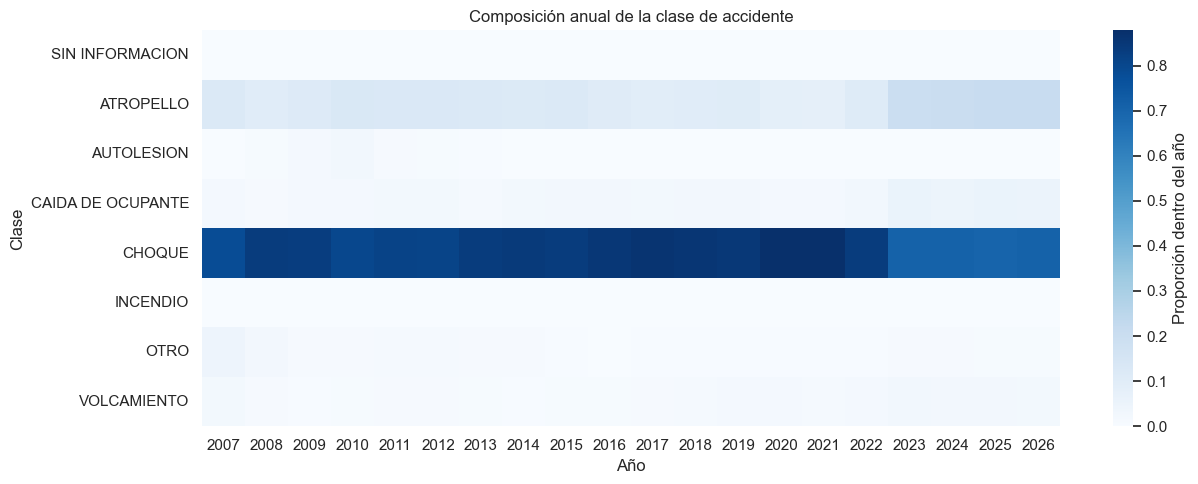

In [6]:
# Distribución temporal de las clases
conteo_anual = pd.crosstab(datos['ANIO'], datos['CLASE_ACCIDENTE'])
conteo_anual.columns = [catalogo_clases.get(codigo, str(codigo)) for codigo in conteo_anual.columns]
display(conteo_anual)

fig, ax = plt.subplots(figsize=(13, 5))
proporcion_anual = conteo_anual.div(conteo_anual.sum(axis=1), axis=0)
sns.heatmap(proporcion_anual.T, cmap='Blues', ax=ax, cbar_kws={'label': 'Proporción dentro del año'})
ax.set_title('Composición anual de la clase de accidente')
ax.set_xlabel('Año')
ax.set_ylabel('Clase')
plt.tight_layout()
plt.show()

In [7]:
# Resumen de las clases que se excluirán o agruparán
clases_a_revisar = [0, 2, 3, 5, 6, 7]
resumen_clases_a_revisar = (
    datos.loc[datos['CLASE_ACCIDENTE'].isin(clases_a_revisar)]
    .groupby('CLASE_ACCIDENTE')
    .agg(
        CASOS=('ACCIDENTE_ID', 'size'),
        PRIMER_ANIO=('ANIO', 'min'),
        ULTIMO_ANIO=('ANIO', 'max'),
        ANIOS_CON_REGISTROS=('ANIO', 'nunique'),
    )
    .reset_index()
)
resumen_clases_a_revisar['DESCRIPCION'] = resumen_clases_a_revisar['CLASE_ACCIDENTE'].map(catalogo_clases)
resumen_clases_a_revisar['PORCENTAJE_TOTAL'] = 100 * resumen_clases_a_revisar['CASOS'] / len(datos)
display(resumen_clases_a_revisar)

,CLASE_ACCIDENTE,CASOS,PRIMER_ANIO,ULTIMO_ANIO,ANIOS_CON_REGISTROS,DESCRIPCION,PORCENTAJE_TOTAL
0,0,278,2007,2008,2,SIN INFORMACION,0.0310
1,2,4383,2008,2017,10,AUTOLESION,0.4895
2,3,20387,2007,2026,20,CAIDA DE OCUPANTE,2.2770
3,5,89,2008,2025,18,INCENDIO,0.0099
4,6,10598,2007,2026,20,OTRO,1.1837
5,7,11559,2007,2026,20,VOLCAMIENTO,1.2910


### Decisión sobre las clases de salida

El objetivo original está fuertemente desbalanceado: `CHOQUE` representa cerca del 83 % y varias categorías tienen muy poco soporte. Para construir una salida operativa más estable se definen tres clases:

- `CHOQUE`: conserva la categoría original `CHOQUE`.
- `ATROPELLO`: conserva la categoría original `ATROPELLO`, por su relevancia y soporte propio.
- `OTROS`: agrupa `AUTOLESION`, `CAIDA DE OCUPANTE`, `INCENDIO`, `OTRO` y `VOLCAMIENTO`.

`SIN INFORMACION` se excluye porque expresa ausencia de registro, no un tipo de accidente. `OTROS` debe interpretarse como una clase residual operativa y no como un mecanismo homogéneo; el agrupamiento mejora el soporte estadístico a cambio de perder detalle entre sus componentes.

In [8]:
# Construir el objetivo agrupado de tres clases
CODIGO_SIN_INFORMACION = 0
AGRUPACION_CLASES = {
    1: 'ATROPELLO',
    2: 'OTROS',
    3: 'OTROS',
    4: 'CHOQUE',
    5: 'OTROS',
    6: 'OTROS',
    7: 'OTROS',
}
datos_modelo = datos.loc[datos['CLASE_ACCIDENTE'].ne(CODIGO_SIN_INFORMACION)].copy()
datos_modelo['CLASE_ACCIDENTE_AGRUPADA'] = (
    datos_modelo['CLASE_ACCIDENTE'].map(AGRUPACION_CLASES)
)
assert datos_modelo['CLASE_ACCIDENTE_AGRUPADA'].notna().all()
assert set(datos_modelo['CLASE_ACCIDENTE_AGRUPADA']) == {'CHOQUE', 'ATROPELLO', 'OTROS'}

print(f'Registros iniciales: {len(datos):,}')
print(f'Registros SIN INFORMACION retirados: {len(datos) - len(datos_modelo):,}')
print(f'Registros para modelado: {len(datos_modelo):,}')

Registros iniciales: 895,346
Registros SIN INFORMACION retirados: 278
Registros para modelado: 895,068


,CASOS,PORCENTAJE
CLASE_ACCIDENTE_AGRUPADA,,
CHOQUE,742846,82.9932
ATROPELLO,105206,11.7540
OTROS,47016,5.2528


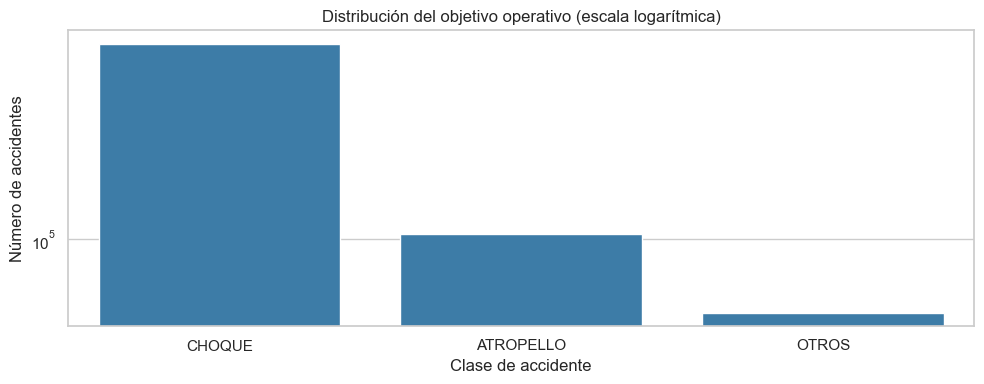

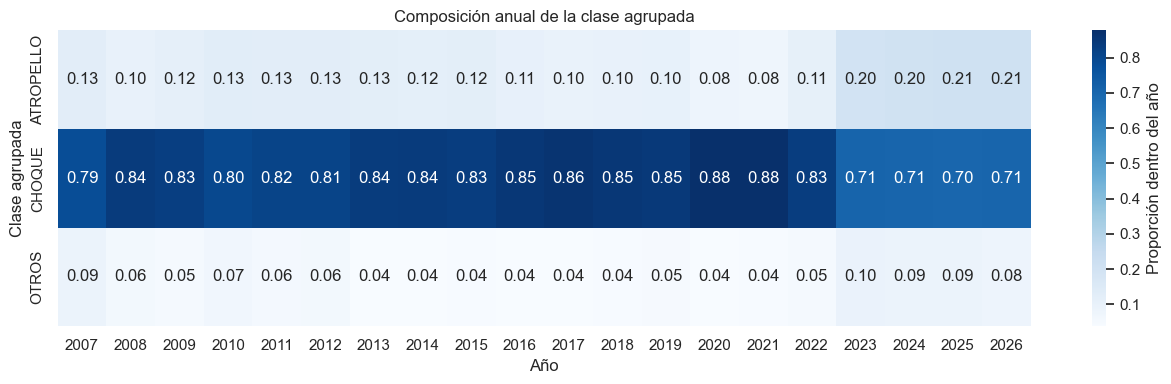

,count,mean,std,min,25%,50%,75%,max
ACCIDENTES,150.0000,"5,967.1200","2,280.7893",283.0000,"4,476.5000","5,739.5000","7,189.0000","11,650.0000"


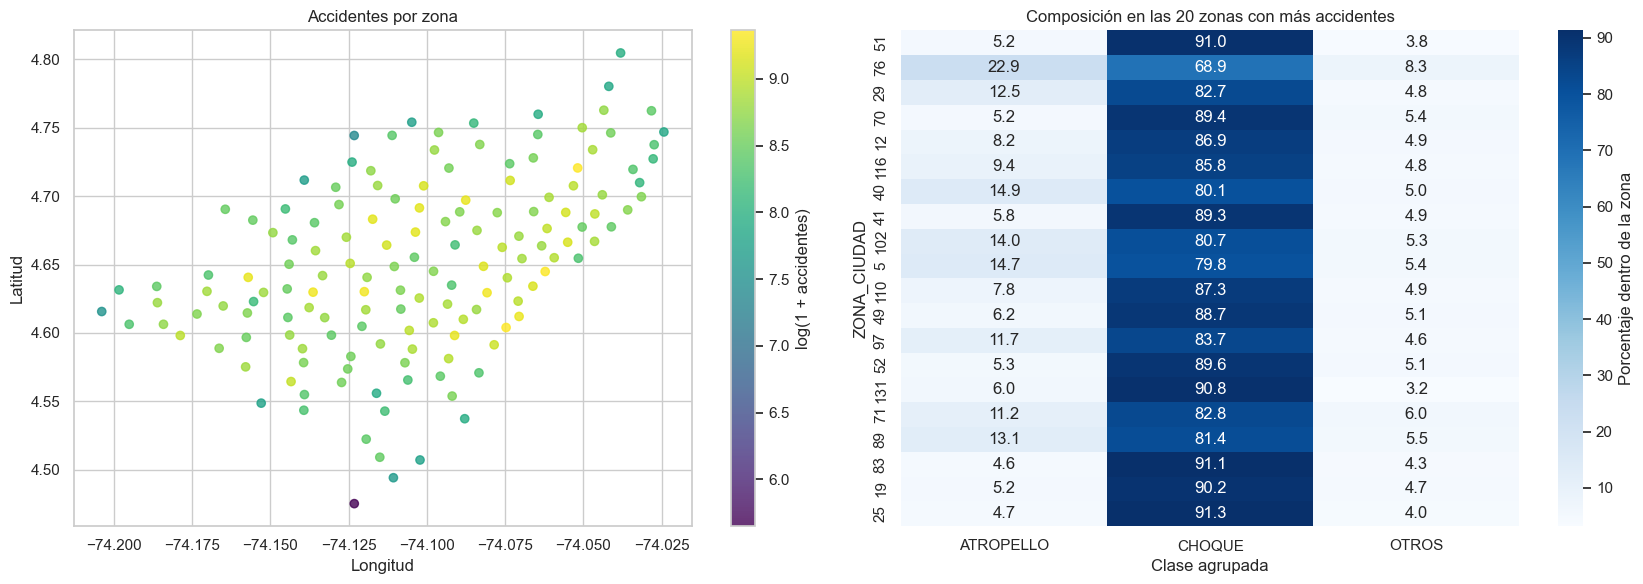

,PORCENTAJE_FALTANTES
N_CALZADAS,45.4484
N_CARRILES,45.4484
GEOMETRIA_PLANTA,0.0000
GEOMETRIA_TERRENO,0.0000
GEOMETRIA_SECCION,0.0000
SENTIDO_VIA,0.0000
SUPERFICIE_RODADURA,0.0000
ESTADO_VIA,0.0000
CONDICION_VIA,0.0000
ILUMINACION_ARTIFICIAL,0.0000


In [9]:
# Desbalance y faltantes de las variables candidatas
resumen_clases_modelo = (
    datos_modelo['CLASE_ACCIDENTE_AGRUPADA'].value_counts().rename('CASOS').to_frame()
)
resumen_clases_modelo['PORCENTAJE'] = 100 * resumen_clases_modelo['CASOS'] / len(datos_modelo)
display(resumen_clases_modelo)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(
    data=resumen_clases_modelo.reset_index(),
    x='CLASE_ACCIDENTE_AGRUPADA', y='CASOS', ax=ax, color='#2C7FB8'
)
ax.set_yscale('log')
ax.set_title('Distribución del objetivo operativo (escala logarítmica)')
ax.set_xlabel('Clase de accidente')
ax.set_ylabel('Número de accidentes')
plt.tight_layout()
plt.show()

# Estabilidad temporal del objetivo agrupado
conteo_anual_agrupado = pd.crosstab(
    datos_modelo['ANIO'], datos_modelo['CLASE_ACCIDENTE_AGRUPADA']
)
proporcion_anual_agrupada = conteo_anual_agrupado.div(
    conteo_anual_agrupado.sum(axis=1), axis=0
)
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    proporcion_anual_agrupada.T, cmap='Blues', annot=True, fmt='.2f', ax=ax,
    cbar_kws={'label': 'Proporción dentro del año'}
)
ax.set_title('Composición anual de la clase agrupada')
ax.set_xlabel('Año')
ax.set_ylabel('Clase agrupada')
plt.tight_layout()
plt.show()

# Volumen y composición de clases por zona
resumen_zonas = (
    datos_modelo.groupby('ZONA_CIUDAD')
    .agg(ACCIDENTES=('ACCIDENTE_ID', 'size'))
    .reset_index()
    .merge(centroides_zona, on='ZONA_CIUDAD', how='left', validate='1:1')
)
composicion_zona = pd.crosstab(
    datos_modelo['ZONA_CIUDAD'],
    datos_modelo['CLASE_ACCIDENTE_AGRUPADA'], normalize='index'
)
assert len(resumen_zonas) == NUMERO_ZONAS
display(resumen_zonas['ACCIDENTES'].describe().to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
dispersion = axes[0].scatter(
    resumen_zonas['LONGITUD_CENTROIDE'], resumen_zonas['LATITUD_CENTROIDE'],
    c=np.log1p(resumen_zonas['ACCIDENTES']), cmap='viridis', alpha=0.8
)
axes[0].set_title('Accidentes por zona')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
fig.colorbar(dispersion, ax=axes[0], label='log(1 + accidentes)')
zonas_mayor_volumen = resumen_zonas.nlargest(20, 'ACCIDENTES')['ZONA_CIUDAD']
sns.heatmap(
    100 * composicion_zona.loc[zonas_mayor_volumen], annot=True, fmt='.1f',
    cmap='Blues', ax=axes[1], cbar_kws={'label': 'Porcentaje dentro de la zona'}
)
axes[1].set_title('Composición en las 20 zonas con más accidentes')
axes[1].set_xlabel('Clase agrupada')
axes[1].set_ylabel('ZONA_CIUDAD')
plt.tight_layout()
plt.show()

faltantes = (
    datos_modelo[COLUMNAS_VIA].isna().mean().mul(100)
    .rename('PORCENTAJE_FALTANTES').sort_values(ascending=False).to_frame()
)
display(faltantes)

## 3. Definición de predictores y control de fuga de información

El momento de predicción es una consulta de ruta, fecha y hora en la que se supone que podría ocurrir un accidente, pero todavía no se conocen sus consecuencias. Por ello se permiten componentes espaciales, temporales, de infraestructura vial y meteorológicos. `ZONA_CIUDAD` representa las mismas 150 zonas aprendidas en el notebook de ocurrencia y se trata como una categoría, no como una magnitud ordinal.

Se bloquean explícitamente identificadores, objetivos y variables construidas después del evento. Incluir `CANTIDAD_PEATONES`, `TIENE_MOTOCICLETA`, `CANTIDAD_HERIDOS` o las causas facilitaría reconocer la clase registrada, pero el desempeño no sería reproducible al consultar una ruta futura.

In [10]:
# Ingeniería temporal y circular
def agregar_variables_ciclicas(df):
    salida = df.copy()
    ciclos = {
        'MES': 12,
        'DIA_SEMANA': 7,
        'HORA': 24,
        'DIRECCION_VIENTO_10M': 360,
    }
    for columna, periodo in ciclos.items():
        angulo = 2 * np.pi * salida[columna].astype(float) / periodo
        salida[f'{columna}_SIN'] = np.sin(angulo)
        salida[f'{columna}_COS'] = np.cos(angulo)
    return salida

datos_modelo = agregar_variables_ciclicas(datos_modelo)

PREDICTORES_NUMERICOS_BASE = [
    'CELDA_X', 'CELDA_Y', 'ANIO',
    'MES_SIN', 'MES_COS', 'DIA_SEMANA_SIN', 'DIA_SEMANA_COS',
    'HORA_SIN', 'HORA_COS', *COLUMNAS_VIA_NUMERICAS
]
PREDICTORES_CATEGORICOS_BASE = [
    'ZONA_CIUDAD', 'MES', 'DIA_SEMANA', 'HORA', *COLUMNAS_VIA_CATEGORICAS
]
PREDICTORES_CLIMA = [
    'TEMPERATURA_2M', 'HUMEDAD_RELATIVA_2M', 'SENSACION_TERMICA',
    'PRECIPITACION', 'LLUVIA', 'NUBOSIDAD', 'PRESION_SUPERFICIE',
    'VELOCIDAD_VIENTO_10M', 'DIRECCION_VIENTO_10M_SIN',
    'DIRECCION_VIENTO_10M_COS'
]

ESCENARIOS = {
    'SIN_CLIMA': {
        'numericas': PREDICTORES_NUMERICOS_BASE,
        'categoricas': PREDICTORES_CATEGORICOS_BASE,
    },
    'CON_CLIMA': {
        'numericas': [*PREDICTORES_NUMERICOS_BASE, *PREDICTORES_CLIMA],
        'categoricas': PREDICTORES_CATEGORICOS_BASE,
    },
}

VARIABLES_POSTEVENTO_BLOQUEADAS = {
    'OBJETIVO_GRAVE', 'CANTIDAD_VEHICULOS', 'CLASES_VEHICULO_DISTINTAS',
    'SERVICIOS_VEHICULO_DISTINTOS', 'TIENE_MOTOCICLETA', 'TIENE_BICICLETA',
    'TIENE_AUTOMOVIL', 'TIENE_BUS', 'TIENE_CAMION', 'CANTIDAD_ACTORES',
    'EDAD_PROMEDIO', 'EDAD_MINIMA', 'EDAD_MAXIMA', 'CANTIDAD_CONDUCTORES',
    'CANTIDAD_PASAJEROS', 'CANTIDAD_PEATONES', 'CANTIDAD_HERIDOS',
    'CANTIDAD_MUERTOS', 'CANTIDAD_CAUSAS', 'CAUSAS_DISTINTAS',
    'TIPOS_CAUSA_DISTINTOS', 'ACCIDENTE_ID', 'CLIMA_ID', 'CLASE_ACCIDENTE',
    'CLASE_ACCIDENTE_AGRUPADA'
}

resumen_escenarios = pd.DataFrame([
    {
        'ESCENARIO': nombre,
        'NUMERICAS': len(grupos['numericas']),
        'CATEGORICAS': len(grupos['categoricas']),
        'TOTAL_ENTRADAS': len(grupos['numericas']) + len(grupos['categoricas'])
    }
    for nombre, grupos in ESCENARIOS.items()
])
display(resumen_escenarios)

,ESCENARIO,NUMERICAS,CATEGORICAS,TOTAL_ENTRADAS
0,SIN_CLIMA,11,13,24
1,CON_CLIMA,21,13,34


## 4. Partición temporal de entrenamiento, validación y prueba

No se usa una división aleatoria. Accidentes cercanos en espacio y tiempo comparten patrones, y mezclarlos aleatoriamente entre entrenamiento y prueba inflaría las métricas. El corte temporal responde a la pregunta relevante: **¿el modelo entrenado con el pasado generaliza a años posteriores?**

- Entrenamiento: 2007–2020.
- Validación y selección: 2021–2023.
- Prueba final: 2024–2026.

In [11]:
ANIO_FIN_ENTRENAMIENTO = 2020
ANIO_FIN_VALIDACION = 2023

mascara_train = datos_modelo['ANIO'] <= ANIO_FIN_ENTRENAMIENTO
mascara_val = datos_modelo['ANIO'].between(ANIO_FIN_ENTRENAMIENTO + 1, ANIO_FIN_VALIDACION)
mascara_test = datos_modelo['ANIO'] > ANIO_FIN_VALIDACION

CLASES_MODELO = ['ATROPELLO', 'CHOQUE', 'OTROS']
encoder_objetivo = LabelEncoder()
encoder_objetivo.fit(CLASES_MODELO)
clases_codificadas = np.arange(len(encoder_objetivo.classes_))

def construir_xy(mascara, escenario):
    columnas = ESCENARIOS[escenario]['numericas'] + ESCENARIOS[escenario]['categoricas']
    X = datos_modelo.loc[mascara, columnas].reset_index(drop=True)
    y_original = datos_modelo.loc[mascara, 'CLASE_ACCIDENTE_AGRUPADA'].to_numpy()
    y = encoder_objetivo.transform(y_original)
    return X, y

X_train_clima, y_train = construir_xy(mascara_train, 'CON_CLIMA')
X_val_clima, y_val = construir_xy(mascara_val, 'CON_CLIMA')
X_test_clima, y_test = construir_xy(mascara_test, 'CON_CLIMA')

resumen_particiones = []
for nombre, mascara, y_particion in [
    ('ENTRENAMIENTO', mascara_train, y_train),
    ('VALIDACION', mascara_val, y_val),
    ('PRUEBA', mascara_test, y_test),
]:
    resumen_particiones.append({
        'PARTICION': nombre,
        'FILAS': int(mascara.sum()),
        'FECHA_MINIMA': datos_modelo.loc[mascara, 'FECHA_HORA'].min(),
        'FECHA_MAXIMA': datos_modelo.loc[mascara, 'FECHA_HORA'].max(),
        'CLASES_PRESENTES': len(np.unique(y_particion)),
    })
display(pd.DataFrame(resumen_particiones))

distribucion_particiones = pd.DataFrame({
    'ENTRENAMIENTO': pd.Series(y_train).value_counts(normalize=True),
    'VALIDACION': pd.Series(y_val).value_counts(normalize=True),
    'PRUEBA': pd.Series(y_test).value_counts(normalize=True),
}).fillna(0).reindex(clases_codificadas, fill_value=0)
distribucion_particiones.index = encoder_objetivo.inverse_transform(
    distribucion_particiones.index.to_numpy()
)
display((100 * distribucion_particiones).round(3))

,PARTICION,FILAS,FECHA_MINIMA,FECHA_MAXIMA,CLASES_PRESENTES
0,ENTRENAMIENTO,795386,2007-01-01 00:00:00,2020-12-31 22:34:00,3
1,VALIDACION,67444,2021-01-01 00:30:00,2023-12-31 23:30:00,3
2,PRUEBA,32238,2024-01-01 00:27:00,2026-08-13 00:50:00,3


,ENTRENAMIENTO,VALIDACION,PRUEBA
ATROPELLO,11.4010,11.5800,20.8230
CHOQUE,83.5300,82.6670,70.4290
OTROS,5.0690,5.7530,8.7470


## 5. Preprocesamiento y métricas

Los códigos categóricos del diccionario no representan distancias u orden. Por esta razón se transforman con *one-hot encoding*. Los valores numéricos faltantes se imputan con la mediana calculada únicamente en entrenamiento y luego se estandarizan. Todo el preprocesamiento queda dentro de cada `Pipeline`, evitando que validación o prueba intervengan en el ajuste.

La clase mayoritaria representa más del 80 % de los registros; por eso `accuracy` no dirige la selección. La métrica primaria es `F1 macro`, acompañada por *balanced accuracy*, PR-AUC macro, ROC-AUC macro y log loss.

In [12]:
def crear_preprocesador(escenario):
    grupos = ESCENARIOS[escenario]
    pipeline_numerico = Pipeline([
        ('imputador', SimpleImputer(strategy='median')),
        ('escalador', StandardScaler()),
    ])
    pipeline_categorico = Pipeline([
        ('imputador', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
    ])
    return ColumnTransformer([
        ('numericas', pipeline_numerico, grupos['numericas']),
        ('categoricas', pipeline_categorico, grupos['categoricas']),
    ], remainder='drop')

def ordenar_probabilidades(modelo, X, clases_esperadas):
    probabilidades = modelo.predict_proba(X)
    clases_modelo = np.asarray(modelo.classes_)
    salida = np.zeros((len(X), len(clases_esperadas)), dtype=float)
    for posicion, clase in enumerate(clases_esperadas):
        coincidencia = np.where(clases_modelo == clase)[0]
        if len(coincidencia):
            salida[:, posicion] = probabilidades[:, coincidencia[0]]
    suma = salida.sum(axis=1, keepdims=True)
    return np.divide(salida, suma, out=np.zeros_like(salida), where=suma > 0)

def error_calibracion_esperado(y_real, probabilidades, n_bins=10):
    confianza = probabilidades.max(axis=1)
    prediccion = probabilidades.argmax(axis=1)
    acierto = (prediccion == y_real).astype(float)
    limites = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for inferior, superior in zip(limites[:-1], limites[1:]):
        mascara = (confianza > inferior) & (confianza <= superior)
        if mascara.any():
            ece += mascara.mean() * abs(acierto[mascara].mean() - confianza[mascara].mean())
    return ece

def calcular_metricas(y_real, probabilidades, clases=clases_codificadas):
    prediccion = clases[np.argmax(probabilidades, axis=1)]
    y_binaria = LabelBinarizer().fit(clases).transform(y_real)
    onehot_real = np.eye(len(clases))[y_real]
    metricas = {
        'Accuracy': accuracy_score(y_real, prediccion),
        'Balanced_Accuracy': balanced_accuracy_score(y_real, prediccion),
        'F1_macro': f1_score(y_real, prediccion, average='macro', zero_division=0),
        'F1_weighted': f1_score(y_real, prediccion, average='weighted', zero_division=0),
        'PR_AUC_macro': average_precision_score(y_binaria, probabilidades, average='macro'),
        'ROC_AUC_OVR_macro': roc_auc_score(y_real, probabilidades, labels=clases, multi_class='ovr', average='macro'),
        'Log_Loss': log_loss(y_real, probabilidades, labels=clases),
        'Brier_multiclase': np.mean(np.sum((probabilidades - onehot_real) ** 2, axis=1)),
        'ECE_10_bins': error_calibracion_esperado(y_real, probabilidades, n_bins=10),
    }
    return metricas

def pesos_clase_suaves(y, potencia=0.50):
    clases, conteos = np.unique(y, return_counts=True)
    maximo = conteos.max()
    return {
        int(clase): float(min((maximo / conteo) ** potencia, 25.0))
        for clase, conteo in zip(clases, conteos)
    }

In [13]:
# Muestra de ajuste que conserva la distribución observada en entrenamiento
TAMANO_MUESTRA_AJUSTE = 250_000

def indices_muestra_ajuste(y, tamano=TAMANO_MUESTRA_AJUSTE, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    cantidad = min(len(y), tamano)
    return np.sort(rng.choice(len(y), size=cantidad, replace=False))

def balancear_para_mlp(X, y, cantidad_por_clase=25_000, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    seleccionados = []
    for clase in np.unique(y):
        indices = np.flatnonzero(y == clase)
        seleccionados.append(rng.choice(indices, size=cantidad_por_clase, replace=len(indices) < cantidad_por_clase))
    seleccionados = rng.permutation(np.concatenate(seleccionados))
    return X.iloc[seleccionados].reset_index(drop=True), y[seleccionados]

indices_ajuste = indices_muestra_ajuste(y_train)
y_ajuste = y_train[indices_ajuste]

distribucion_muestra = pd.DataFrame({
    'ENTRENAMIENTO_COMPLETO': pd.Series(y_train).value_counts(normalize=True),
    'MUESTRA_AJUSTE': pd.Series(y_ajuste).value_counts(normalize=True),
}).fillna(0).reindex(clases_codificadas, fill_value=0)
distribucion_muestra.index = encoder_objetivo.inverse_transform(
    distribucion_muestra.index.to_numpy()
)
display((100 * distribucion_muestra).round(3))
print(f'Tamaño de la muestra de ajuste: {len(y_ajuste):,}')

,ENTRENAMIENTO_COMPLETO,MUESTRA_AJUSTE
ATROPELLO,11.4010,11.4060
CHOQUE,83.5300,83.5360
OTROS,5.0690,5.0580


Tamaño de la muestra de ajuste: 250,000


## 6. Línea base y modelos candidatos

La línea base reproduce las probabilidades históricas de cada clase. Un modelo útil debe mejorarla, especialmente en `F1 macro` y *balanced accuracy*.

Las configuraciones candidatas son deliberadamente acotadas: permiten comparar hipótesis del curso sin realizar una búsqueda masiva que sobreajuste el único periodo de validación.

In [14]:
# Línea base de prevalencia histórica
baseline = DummyClassifier(strategy='prior', random_state=SEMILLA)
baseline.fit(np.zeros((len(y_train), 1)), y_train)
proba_baseline_val = ordenar_probabilidades(baseline, np.zeros((len(y_val), 1)), clases_codificadas)
metricas_baseline = calcular_metricas(y_val, proba_baseline_val)
display(pd.DataFrame([{'MODELO': 'BASELINE_PRIOR', **metricas_baseline}]))

,MODELO,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,BASELINE_PRIOR,0.8267,0.3333,0.3017,0.7482,0.3333,0.5000,0.5718,0.3000,0.0086


In [15]:
# Corridas de calibración: varios puntos por familia, siguiendo la lógica de los talleres
CONFIGURACIONES = {
    'REGRESION_LOGISTICA': [
        {'C': 0.05, 'potencia_peso': 0.25},
        {'C': 0.25, 'potencia_peso': 0.25},
        {'C': 1.00, 'potencia_peso': 0.25},
        {'C': 0.25, 'potencia_peso': 0.50},
        {'C': 0.25, 'potencia_peso': 0.75},
    ],
    'RANDOM_FOREST': [
        {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25},
        {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25},
        {'n_estimators': 100, 'max_depth': 24, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25},
        {'n_estimators': 160, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25},
        {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'potencia_peso': 0.25},
        {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.50},
    ],
    'XGBOOST': [
        {'n_estimators': 160, 'max_depth': 3, 'learning_rate': 0.05, 'min_child_weight': 10, 'potencia_peso': 0.25},
        {'n_estimators': 240, 'max_depth': 3, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.25},
        {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.03, 'min_child_weight': 10, 'potencia_peso': 0.25},
        {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.25},
        {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.25},
        {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.50},
        {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.50},
        {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75},
    ],
    'MLP': [
        {'hidden_layer_sizes': (32,), 'alpha': 0.001, 'learning_rate_init': 0.001},
        {'hidden_layer_sizes': (64, 32), 'alpha': 0.001, 'learning_rate_init': 0.001},
        {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.003, 'learning_rate_init': 0.0007},
    ],
}

def crear_modelo(nombre, escenario, parametros, y_referencia):
    preprocesador = crear_preprocesador(escenario)
    parametros_modelo = parametros.copy()
    potencia_peso = parametros_modelo.pop('potencia_peso', 0.50)
    pesos = pesos_clase_suaves(y_referencia, potencia=potencia_peso)

    if nombre == 'REGRESION_LOGISTICA':
        estimador = LogisticRegression(
            C=parametros_modelo['C'], class_weight=pesos, solver='lbfgs',
            max_iter=500, random_state=SEMILLA, n_jobs=-1
        )
    elif nombre == 'RANDOM_FOREST':
        estimador = RandomForestClassifier(
            **parametros_modelo, class_weight=pesos, max_samples=0.75,
            random_state=SEMILLA, n_jobs=-1
        )
    elif nombre == 'XGBOOST':
        estimador = XGBClassifier(
            **parametros_modelo, objective='multi:softprob', eval_metric='mlogloss',
            subsample=0.85, colsample_bytree=0.85, reg_lambda=2.0,
            tree_method='hist', random_state=SEMILLA, n_jobs=-1
        )
    elif nombre == 'MLP':
        estimador = MLPClassifier(
            **parametros_modelo, activation='relu', solver='adam', batch_size=1024,
            max_iter=60, early_stopping=True, validation_fraction=0.12,
            n_iter_no_change=5, tol=0.001, random_state=SEMILLA
        )
    else:
        raise ValueError(f'Modelo no reconocido: {nombre}')

    return Pipeline([('preprocesador', preprocesador), ('modelo', estimador)])

def ajustar_modelo(nombre, escenario, parametros, X, y):
    X_entrenar, y_entrenar = X, y
    if nombre == 'MLP':
        X_entrenar, y_entrenar = balancear_para_mlp(X, y)
    modelo = crear_modelo(nombre, escenario, parametros, y_entrenar)
    inicio = perf_counter()
    if nombre == 'XGBOOST':
        pesos = pesos_clase_suaves(y_entrenar, potencia=parametros.get('potencia_peso', 0.50))
        sample_weight = np.array([pesos[int(clase)] for clase in y_entrenar])
        modelo.fit(X_entrenar, y_entrenar, modelo__sample_weight=sample_weight)
    else:
        modelo.fit(X_entrenar, y_entrenar)
    return modelo, perf_counter() - inicio

## 7. Evaluación de modelos en cascada

Cada familia se trabaja por separado. Las configuraciones se calibran de manera independiente en los escenarios con y sin clima; en cada uno se elige la de mayor `F1 macro`, usando `log loss` como desempate. Así, la comparación climática no favorece a un escenario por reutilizar parámetros optimizados para el otro.

In [16]:
# Preparar los dos escenarios sobre exactamente las mismas filas
datos_escenario = {}
for escenario in ESCENARIOS:
    X_train_escenario, _ = construir_xy(mascara_train, escenario)
    X_val_escenario, _ = construir_xy(mascara_val, escenario)
    datos_escenario[escenario] = {
        'ajuste': X_train_escenario.iloc[indices_ajuste].reset_index(drop=True),
        'validacion': X_val_escenario,
    }

resultados_ajuste_acumulados = []
resultados_validacion = [
    {'MODELO': 'BASELINE_PRIOR', 'ESCENARIO': 'SIN_PREDICTORES', 'SEGUNDOS_AJUSTE': 0.0, **metricas_baseline}
]
mejores_parametros = {}
modelos_validacion = {}
probabilidades_validacion = {}

def evaluar_familia(nombre_modelo):
    tablas_ajuste = []
    filas_comparacion = []

    for escenario in ESCENARIOS:
        filas_escenario = []
        modelos_candidatos = {}
        probabilidades_candidatas = {}
        X_ajuste = datos_escenario[escenario]['ajuste']
        X_validacion = datos_escenario[escenario]['validacion']

        for numero, parametros in enumerate(CONFIGURACIONES[nombre_modelo], start=1):
            print(
                f'{escenario}: configuración {numero}/'
                f'{len(CONFIGURACIONES[nombre_modelo])}: {parametros}'
            )
            modelo, segundos = ajustar_modelo(
                nombre_modelo, escenario, parametros, X_ajuste, y_ajuste
            )
            probabilidades = ordenar_probabilidades(
                modelo, X_validacion, clases_codificadas
            )
            filas_escenario.append({
                'MODELO': nombre_modelo, 'ESCENARIO': escenario,
                'CONFIGURACION': numero,
                'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
                'SEGUNDOS_AJUSTE': segundos,
                **calcular_metricas(y_val, probabilidades),
            })
            modelos_candidatos[numero] = modelo
            probabilidades_candidatas[numero] = probabilidades

        tabla_escenario = pd.DataFrame(filas_escenario)
        mejor = tabla_escenario.sort_values(
            ['F1_macro', 'Log_Loss'], ascending=[False, True]
        ).iloc[0]
        numero_mejor = int(mejor['CONFIGURACION'])
        parametros_mejores = CONFIGURACIONES[nombre_modelo][numero_mejor - 1]
        modelo_mejor = modelos_candidatos[numero_mejor]
        proba_mejor = probabilidades_candidatas[numero_mejor]

        mejores_parametros[(nombre_modelo, escenario)] = parametros_mejores
        modelos_validacion[(nombre_modelo, escenario)] = modelo_mejor
        probabilidades_validacion[(nombre_modelo, escenario)] = proba_mejor
        filas_comparacion.append({
            'MODELO': nombre_modelo, 'ESCENARIO': escenario,
            'SEGUNDOS_AJUSTE': float(mejor['SEGUNDOS_AJUSTE']),
            **calcular_metricas(y_val, proba_mejor),
        })
        tablas_ajuste.append(tabla_escenario)
        print(
            f'Mejor configuración para {escenario}: {numero_mejor} — '
            f'{parametros_mejores}'
        )

    tabla_ajuste = pd.concat(tablas_ajuste, ignore_index=True)
    comparacion = pd.DataFrame(filas_comparacion)
    resultados_ajuste_acumulados.append(tabla_ajuste)
    resultados_validacion.extend(comparacion.to_dict('records'))

    display(tabla_ajuste)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for escenario, grupo in tabla_ajuste.groupby('ESCENARIO'):
        axes[0].plot(
            grupo['CONFIGURACION'], grupo['F1_macro'], marker='o',
            label=f'F1 macro — {escenario}'
        )
        axes[1].plot(
            grupo['CONFIGURACION'], grupo['Log_Loss'], marker='o',
            label=escenario
        )
    axes[0].set(title='F1 macro por configuración', xlabel='Configuración', ylabel='F1 macro')
    axes[0].set_xticks(sorted(tabla_ajuste['CONFIGURACION'].unique()))
    axes[0].legend()
    axes[1].set(title='Pérdida probabilística', xlabel='Configuración', ylabel='Log loss')
    axes[1].set_xticks(sorted(tabla_ajuste['CONFIGURACION'].unique()))
    axes[1].legend()
    plt.suptitle(nombre_modelo.replace('_', ' ').title())
    plt.tight_layout()
    plt.show()
    display(comparacion)
    return tabla_ajuste, comparacion

### 7.1 Regresión logística

Se inicia con el modelo más simple e interpretable. Se prueban distintos valores de regularización `C` y tres intensidades de ponderación de las clases.

SIN_CLIMA: configuración 1/5: {'C': 0.05, 'potencia_peso': 0.25}


SIN_CLIMA: configuración 2/5: {'C': 0.25, 'potencia_peso': 0.25}


SIN_CLIMA: configuración 3/5: {'C': 1.0, 'potencia_peso': 0.25}


SIN_CLIMA: configuración 4/5: {'C': 0.25, 'potencia_peso': 0.5}


SIN_CLIMA: configuración 5/5: {'C': 0.25, 'potencia_peso': 0.75}


...

CON_CLIMA: configuración 3/5: {'C': 1.0, 'potencia_peso': 0.25}


CON_CLIMA: configuración 4/5: {'C': 0.25, 'potencia_peso': 0.5}


CON_CLIMA: configuración 5/5: {'C': 0.25, 'potencia_peso': 0.75}


Mejor configuración para CON_CLIMA: 5 — {'C': 0.25, 'potencia_peso': 0.75}


,MODELO,ESCENARIO,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,REGRESION_LOGISTICA,SIN_CLIMA,1,"{""C"": 0.05, ""potencia_peso"": 0.25}",8.2296,0.8259,0.3356,0.3073,0.7499,0.3840,0.6145,0.5612,0.2975,0.0353
1,REGRESION_LOGISTICA,SIN_CLIMA,2,"{""C"": 0.25, ""potencia_peso"": 0.25}",8.9303,0.8258,0.3359,0.3081,0.7501,0.3841,0.6145,0.5615,0.2975,0.0354
2,REGRESION_LOGISTICA,SIN_CLIMA,3,"{""C"": 1.0, ""potencia_peso"": 0.25}",8.4677,0.8258,0.3358,0.3078,0.7500,0.3842,0.6147,0.5615,0.2976,0.0357
3,REGRESION_LOGISTICA,SIN_CLIMA,4,"{""C"": 0.25, ""potencia_peso"": 0.5}",10.6009,0.8113,0.3542,0.3468,0.7568,0.3845,0.6149,0.6032,0.3265,0.1052
4,REGRESION_LOGISTICA,SIN_CLIMA,5,"{""C"": 0.25, ""potencia_peso"": 0.75}",10.8184,0.7464,0.3880,0.3804,0.7370,0.3847,0.6145,0.7123,0.4010,0.1440
5,REGRESION_LOGISTICA,CON_CLIMA,1,"{""C"": 0.05, ""potencia_peso"": 0.25}",11.5542,0.8258,0.3352,0.3065,0.7495,0.3838,0.6143,0.5611,0.2972,0.0345
6,REGRESION_LOGISTICA,CON_CLIMA,2,"{""C"": 0.25, ""potencia_peso"": 0.25}",13.4368,0.8259,0.3360,0.3082,0.7502,0.3839,0.6142,0.5616,0.2974,0.0353
7,REGRESION_LOGISTICA,CON_CLIMA,3,"{""C"": 1.0, ""potencia_peso"": 0.25}",12.4065,0.8259,0.3357,0.3077,0.7500,0.3841,0.6145,0.5614,0.2973,0.0350
8,REGRESION_LOGISTICA,CON_CLIMA,4,"{""C"": 0.25, ""potencia_peso"": 0.5}",14.5453,0.8124,0.3539,0.3461,0.7571,0.3845,0.6147,0.6023,0.3258,0.1051
9,REGRESION_LOGISTICA,CON_CLIMA,5,"{""C"": 0.25, ""potencia_peso"": 0.75}",15.0441,0.7464,0.3893,0.3819,0.7374,0.3846,0.6143,0.7119,0.4007,0.1437


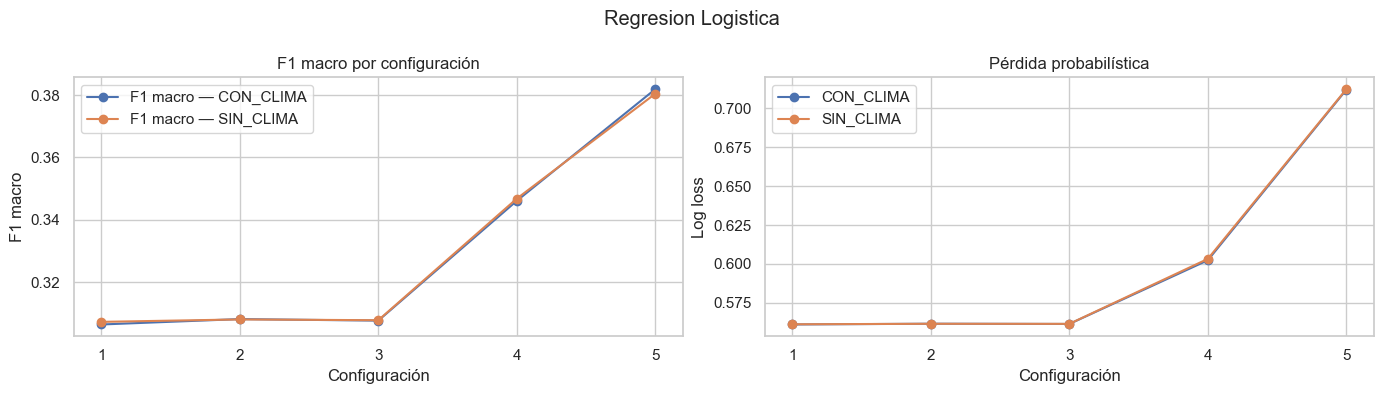

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,REGRESION_LOGISTICA,SIN_CLIMA,10.8184,0.7464,0.3880,0.3804,0.7370,0.3847,0.6145,0.7123,0.4010,0.1440
1,REGRESION_LOGISTICA,CON_CLIMA,15.0441,0.7464,0.3893,0.3819,0.7374,0.3846,0.6143,0.7119,0.4007,0.1437


In [17]:
resultados_logistica, comparacion_logistica = evaluar_familia('REGRESION_LOGISTICA')

**Conclusión de regresión logística.** Los cambios en `C` entre 0,05 y 1,00 producen diferencias pequeñas. El cambio importante aparece al aumentar la ponderación de las clases minoritarias: la configuración 5 (`C=0,25`, potencia `0,75`) alcanza el mayor F1 macro. El costo es elevar el *log loss* desde aproximadamente 0,56 hasta 0,71. Después de calibrar cada escenario por separado, el modelo con clima obtiene F1 macro de 0,3819 frente a 0,3804 sin clima; la diferencia es mínima.

### 7.2 Random Forest

Se continúa con Random Forest para evaluar si un ensamble de árboles captura relaciones no lineales. Se varían profundidad, número de árboles, tamaño mínimo de hoja e intensidad del peso de clase.

SIN_CLIMA: configuración 1/6: {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25}


SIN_CLIMA: configuración 2/6: {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25}


SIN_CLIMA: configuración 3/6: {'n_estimators': 100, 'max_depth': 24, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25}


SIN_CLIMA: configuración 4/6: {'n_estimators': 160, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25}


SIN_CLIMA: configuración 5/6: {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'potencia_peso': 0.25}


...

CON_CLIMA: configuración 4/6: {'n_estimators': 160, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25}


CON_CLIMA: configuración 5/6: {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'potencia_peso': 0.25}


CON_CLIMA: configuración 6/6: {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.5}


Mejor configuración para CON_CLIMA: 6 — {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.5}


,MODELO,ESCENARIO,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,RANDOM_FOREST,SIN_CLIMA,1,"{""n_estimators"": 100, ""max_depth"": 12, ""min_sa...",7.3655,0.8267,0.3333,0.3017,0.7482,0.3798,0.6052,0.5750,0.3029,0.0765
1,RANDOM_FOREST,SIN_CLIMA,2,"{""n_estimators"": 100, ""max_depth"": 18, ""min_sa...",15.3350,0.8267,0.3334,0.3019,0.7483,0.3855,0.6170,0.5696,0.3006,0.0710
2,RANDOM_FOREST,SIN_CLIMA,3,"{""n_estimators"": 100, ""max_depth"": 24, ""min_sa...",26.4612,0.8266,0.3333,0.3018,0.7482,0.3874,0.6205,0.5670,0.2994,0.0676
3,RANDOM_FOREST,SIN_CLIMA,4,"{""n_estimators"": 160, ""max_depth"": 18, ""min_sa...",24.3893,0.8267,0.3333,0.3017,0.7482,0.3861,0.6183,0.5692,0.3003,0.0705
4,RANDOM_FOREST,SIN_CLIMA,5,"{""n_estimators"": 100, ""max_depth"": 18, ""min_sa...",12.4299,0.8267,0.3333,0.3017,0.7482,0.3850,0.6175,0.5709,0.3013,0.0739
5,RANDOM_FOREST,SIN_CLIMA,6,"{""n_estimators"": 100, ""max_depth"": 18, ""min_sa...",15.8906,0.8255,0.3362,0.3089,0.7502,0.3856,0.6154,0.6341,0.3403,0.1743
6,RANDOM_FOREST,CON_CLIMA,1,"{""n_estimators"": 100, ""max_depth"": 12, ""min_sa...",10.4634,0.8267,0.3333,0.3017,0.7482,0.3780,0.6014,0.5747,0.3025,0.0737
7,RANDOM_FOREST,CON_CLIMA,2,"{""n_estimators"": 100, ""max_depth"": 18, ""min_sa...",25.3781,0.8267,0.3333,0.3017,0.7482,0.3813,0.6074,0.5684,0.2993,0.0627
8,RANDOM_FOREST,CON_CLIMA,3,"{""n_estimators"": 100, ""max_depth"": 24, ""min_sa...",45.7234,0.8267,0.3333,0.3017,0.7482,0.3820,0.6089,0.5648,0.2975,0.0539
9,RANDOM_FOREST,CON_CLIMA,4,"{""n_estimators"": 160, ""max_depth"": 18, ""min_sa...",40.7673,0.8267,0.3333,0.3017,0.7482,0.3824,0.6104,0.5680,0.2991,0.0627


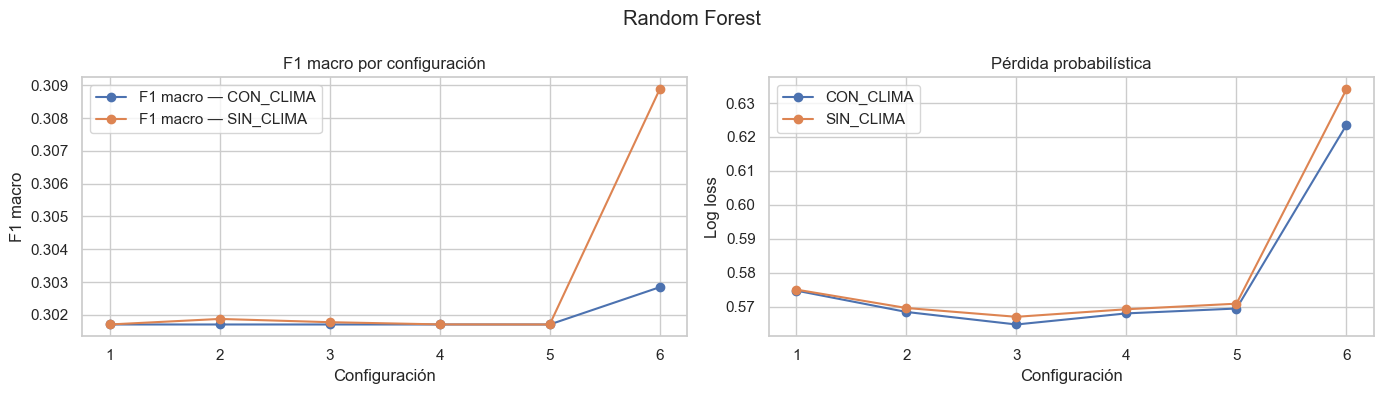

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,RANDOM_FOREST,SIN_CLIMA,15.8906,0.8255,0.3362,0.3089,0.7502,0.3856,0.6154,0.6341,0.3403,0.1743
1,RANDOM_FOREST,CON_CLIMA,27.6315,0.8264,0.3337,0.3028,0.7485,0.3820,0.6086,0.6236,0.3323,0.1601


In [18]:
resultados_rf, comparacion_rf = evaluar_familia('RANDOM_FOREST')

**Conclusión de Random Forest.** La mayoría de las configuraciones se mantienen cerca de la línea base porque predicen principalmente `CHOQUE`. La configuración 6, con mayor peso para las clases minoritarias, es la mejor de la familia. Aun así, solo alcanza F1 macro de 0,3089 sin clima y 0,3028 con clima. El clima reduce el *log loss*, pero empeora F1 macro, *balanced accuracy*, PR-AUC y ROC-AUC.

### 7.3 XGBoost

El tercer bloque evalúa *boosting*. Se combinan número de árboles, profundidad, tasa de aprendizaje, peso mínimo de los nodos e intensidad de ponderación de clases.

SIN_CLIMA: configuración 1/8: {'n_estimators': 160, 'max_depth': 3, 'learning_rate': 0.05, 'min_child_weight': 10, 'potencia_peso': 0.25}


SIN_CLIMA: configuración 2/8: {'n_estimators': 240, 'max_depth': 3, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.25}


SIN_CLIMA: configuración 3/8: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.03, 'min_child_weight': 10, 'potencia_peso': 0.25}


SIN_CLIMA: configuración 4/8: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.25}


SIN_CLIMA: configuración 5/8: {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.25}


...

CON_CLIMA: configuración 6/8: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.5}


CON_CLIMA: configuración 7/8: {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.5}


CON_CLIMA: configuración 8/8: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75}


Mejor configuración para CON_CLIMA: 8 — {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75}


,MODELO,ESCENARIO,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,SIN_CLIMA,1,"{""n_estimators"": 160, ""max_depth"": 3, ""learnin...",2.7943,0.8267,0.3333,0.3017,0.7482,0.3893,0.6206,0.5592,0.2948,0.0451
1,XGBOOST,SIN_CLIMA,2,"{""n_estimators"": 240, ""max_depth"": 3, ""learnin...",3.8832,0.8266,0.3335,0.3020,0.7483,0.3929,0.6286,0.5546,0.2929,0.0362
2,XGBOOST,SIN_CLIMA,3,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",5.2307,0.8266,0.3335,0.3022,0.7483,0.3947,0.6330,0.5544,0.2925,0.0391
3,XGBOOST,SIN_CLIMA,4,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",4.7235,0.8266,0.3346,0.3047,0.7490,0.3962,0.6366,0.5508,0.2912,0.0269
4,XGBOOST,SIN_CLIMA,5,"{""n_estimators"": 320, ""max_depth"": 7, ""learnin...",7.4890,0.8264,0.3355,0.3067,0.7494,0.3958,0.6370,0.5505,0.2912,0.0232
5,XGBOOST,SIN_CLIMA,6,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",4.8712,0.8236,0.3423,0.3228,0.7533,0.3950,0.6354,0.5981,0.3178,0.1267
6,XGBOOST,SIN_CLIMA,7,"{""n_estimators"": 320, ""max_depth"": 7, ""learnin...",7.8924,0.8235,0.3451,0.3287,0.7549,0.3954,0.6362,0.5927,0.3148,0.1172
7,XGBOOST,SIN_CLIMA,8,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",5.9878,0.7947,0.3782,0.3853,0.7593,0.3934,0.6325,0.7156,0.3968,0.2184
8,XGBOOST,CON_CLIMA,1,"{""n_estimators"": 160, ""max_depth"": 3, ""learnin...",4.6430,0.8267,0.3333,0.3017,0.7482,0.3893,0.6212,0.5597,0.2950,0.0472
9,XGBOOST,CON_CLIMA,2,"{""n_estimators"": 240, ""max_depth"": 3, ""learnin...",5.0740,0.8266,0.3336,0.3024,0.7483,0.3923,0.6277,0.5546,0.2929,0.0347


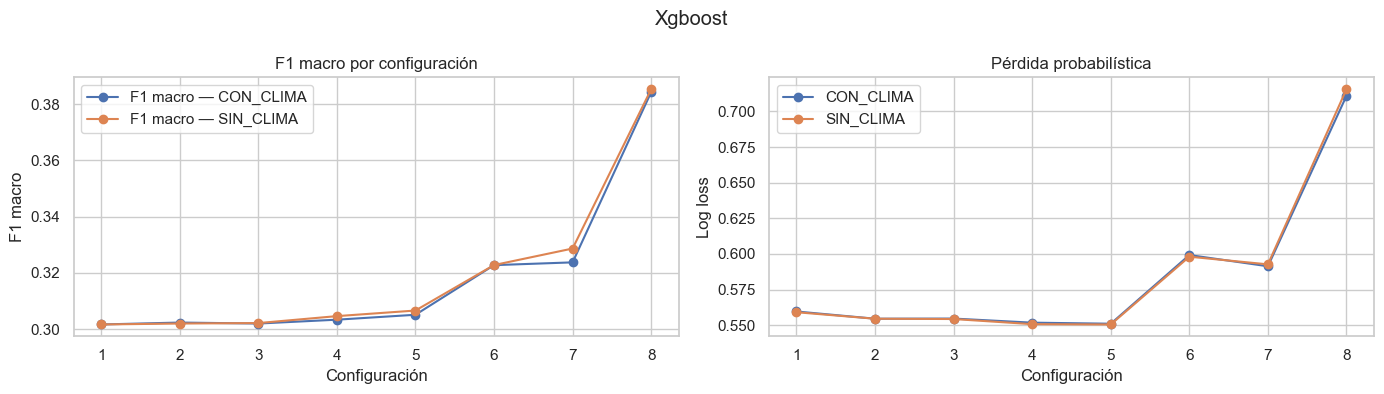

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,SIN_CLIMA,5.9878,0.7947,0.3782,0.3853,0.7593,0.3934,0.6325,0.7156,0.3968,0.2184
1,XGBOOST,CON_CLIMA,6.8709,0.7973,0.3775,0.3843,0.7605,0.3929,0.6288,0.7109,0.3936,0.2178


In [19]:
resultados_xgb, comparacion_xgb = evaluar_familia('XGBOOST')

**Conclusión de XGBoost.** Las ponderaciones suaves entregan las mejores probabilidades, mientras que una ponderación de 0,75 aumenta la detección de `ATROPELLO` y `OTROS`. La configuración 8 (`240` árboles, profundidad `5`, tasa `0,08`, potencia de peso `0,75`) obtiene el mayor F1 macro en ambos escenarios. El modelo sin clima supera levemente al modelo con clima en F1 macro (0,3853 frente a 0,3843), *balanced accuracy*, PR-AUC y ROC-AUC. El clima reduce el *log loss* en 0,0047, pero no mejora la clasificación.

### 7.4 Red neuronal MLP

Finalmente se prueban tres arquitecturas de complejidad creciente. Debido al desbalance, la red se entrena con una muestra balanceada interna y *early stopping*.

SIN_CLIMA: configuración 1/3: {'hidden_layer_sizes': (32,), 'alpha': 0.001, 'learning_rate_init': 0.001}


SIN_CLIMA: configuración 2/3: {'hidden_layer_sizes': (64, 32), 'alpha': 0.001, 'learning_rate_init': 0.001}


SIN_CLIMA: configuración 3/3: {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.003, 'learning_rate_init': 0.0007}


Mejor configuración para SIN_CLIMA: 1 — {'hidden_layer_sizes': (32,), 'alpha': 0.001, 'learning_rate_init': 0.001}
CON_CLIMA: configuración 1/3: {'hidden_layer_sizes': (32,), 'alpha': 0.001, 'learning_rate_init': 0.001}


CON_CLIMA: configuración 2/3: {'hidden_layer_sizes': (64, 32), 'alpha': 0.001, 'learning_rate_init': 0.001}


CON_CLIMA: configuración 3/3: {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.003, 'learning_rate_init': 0.0007}


/Users/leonardoguzman/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


Mejor configuración para CON_CLIMA: 1 — {'hidden_layer_sizes': (32,), 'alpha': 0.001, 'learning_rate_init': 0.001}


,MODELO,ESCENARIO,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,MLP,SIN_CLIMA,1,"{""hidden_layer_sizes"": [32], ""alpha"": 0.001, ""...",3.7711,0.5596,0.4117,0.3582,0.6268,0.3749,0.6003,0.9359,0.5581,0.0360
1,MLP,SIN_CLIMA,2,"{""hidden_layer_sizes"": [64, 32], ""alpha"": 0.00...",14.8430,0.4559,0.3965,0.3170,0.5421,0.3629,0.5749,1.1168,0.6774,0.1381
2,MLP,SIN_CLIMA,3,"{""hidden_layer_sizes"": [128, 64, 32], ""alpha"":...",199.7340,0.4762,0.3898,0.3231,0.5586,0.3607,0.5616,1.5858,0.7518,0.2438
3,MLP,CON_CLIMA,1,"{""hidden_layer_sizes"": [32], ""alpha"": 0.001, ""...",5.9705,0.5491,0.4139,0.3570,0.6183,0.3729,0.6006,0.9439,0.5656,0.0277
4,MLP,CON_CLIMA,2,"{""hidden_layer_sizes"": [64, 32], ""alpha"": 0.00...",111.0158,0.4275,0.3940,0.3046,0.5179,0.3618,0.5708,1.2232,0.7343,0.2027
5,MLP,CON_CLIMA,3,"{""hidden_layer_sizes"": [128, 64, 32], ""alpha"":...",236.3822,0.5650,0.3829,0.3473,0.6280,0.3597,0.5611,1.4976,0.6411,0.1629


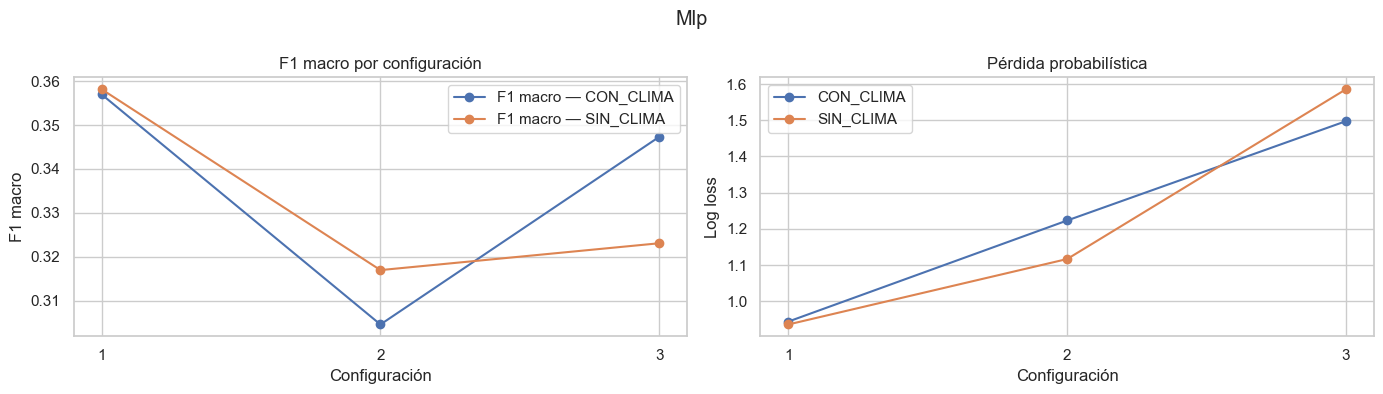

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,MLP,SIN_CLIMA,3.7711,0.5596,0.4117,0.3582,0.6268,0.3749,0.6003,0.9359,0.5581,0.0360
1,MLP,CON_CLIMA,5.9705,0.5491,0.4139,0.3570,0.6183,0.3729,0.6006,0.9439,0.5656,0.0277


In [20]:
resultados_mlp, comparacion_mlp = evaluar_familia('MLP')

**Conclusión de la MLP.** La arquitectura más sencilla, con una capa de 32 unidades, obtiene el mayor F1 macro de la familia; las redes profundas requieren mucho más tiempo y una de ellas no converge dentro de 60 iteraciones. La MLP alcanza la mayor *balanced accuracy* en validación, pero su F1 macro (0,3582 sin clima y 0,3570 con clima) queda por debajo de regresión logística y XGBoost. El clima no aporta una mejora consistente.

## 8. Comparación final de modelos e impacto del clima

Una vez elegido el mejor conjunto de parámetros dentro de cada familia, se consolidan los cuatro ganadores locales y sus versiones con y sin clima.

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,SIN_CLIMA,5.9878,0.7947,0.3782,0.3853,0.7593,0.3934,0.6325,0.7156,0.3968,0.2184
1,XGBOOST,CON_CLIMA,6.8709,0.7973,0.3775,0.3843,0.7605,0.3929,0.6288,0.7109,0.3936,0.2178
2,REGRESION_LOGISTICA,CON_CLIMA,15.0441,0.7464,0.3893,0.3819,0.7374,0.3846,0.6143,0.7119,0.4007,0.1437
3,REGRESION_LOGISTICA,SIN_CLIMA,10.8184,0.7464,0.3880,0.3804,0.7370,0.3847,0.6145,0.7123,0.4010,0.1440
4,MLP,SIN_CLIMA,3.7711,0.5596,0.4117,0.3582,0.6268,0.3749,0.6003,0.9359,0.5581,0.0360
5,MLP,CON_CLIMA,5.9705,0.5491,0.4139,0.3570,0.6183,0.3729,0.6006,0.9439,0.5656,0.0277
6,RANDOM_FOREST,SIN_CLIMA,15.8906,0.8255,0.3362,0.3089,0.7502,0.3856,0.6154,0.6341,0.3403,0.1743
7,RANDOM_FOREST,CON_CLIMA,27.6315,0.8264,0.3337,0.3028,0.7485,0.3820,0.6086,0.6236,0.3323,0.1601
8,BASELINE_PRIOR,SIN_PREDICTORES,0.0000,0.8267,0.3333,0.3017,0.7482,0.3333,0.5000,0.5718,0.3000,0.0086


F1_macro           Balanced_Accuracy            \
ESCENARIO           CON_CLIMA SIN_CLIMA         CON_CLIMA SIN_CLIMA   
MODELO                                                                
MLP                    0.3570    0.3582            0.4139    0.4117   
RANDOM_FOREST          0.3028    0.3089            0.3337    0.3362   
REGRESION_LOGISTICA    0.3819    0.3804            0.3893    0.3880   
XGBOOST                0.3843    0.3853            0.3775    0.3782   

                    PR_AUC_macro           ROC_AUC_OVR_macro            \
ESCENARIO              CON_CLIMA SIN_CLIMA         CON_CLIMA SIN_CLIMA   
MODELO                                                                   
MLP                       0.3729    0.3749            0.6006    0.6003   
RANDOM_FOREST             0.3820    0.3856            0.6086    0.6154   
REGRESION_LOGISTICA       0.3846    0.3847            0.6143    0.6145   
XGBOOST                   0.3929    0.3934            0.6288    0.6325   

                     Log_Loss              F1_macro Balanced_Accuracy  \
ESCENARIO           CON_CLIMA SIN_CLIMA DELTA_CLIMA       DELTA_CLIMA   
MODELO                                                                  
MLP                    0.9439    0.9359     -0.0012            0.0021   
RANDOM_FOREST          0.6236    0.6341     -0.0060           -0.0024   
REGRESION_LOGISTICA    0.7119    0.7123      0.0015            0.0013   
XGBOOST                0.7109    0.7156     -0.0010           -0.0007   

                    PR_AUC_macro ROC_AUC_OVR_macro    Log_Loss  
ESCENARIO            DELTA_CLIMA       DELTA_CLIMA DELTA_CLIMA  
MODELO                                                          
MLP                      -0.0020            0.0003     -0.0080  
RANDOM_FOREST            -0.0036           -0.0068      0.0105  
REGRESION_LOGISTICA      -0.0000           -0.0002      0.0004  
XGBOOST                  -0.0004           -0.0037      0.0047

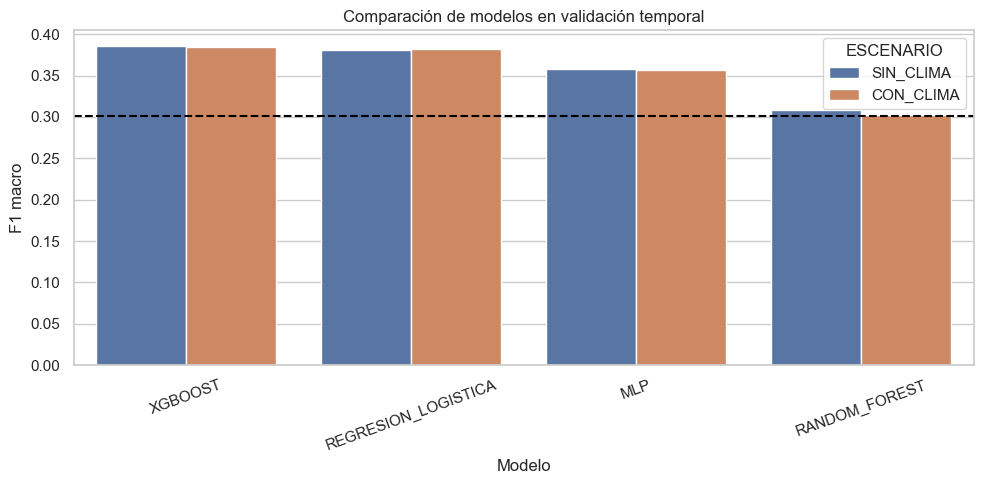

In [21]:
# Comparación directa del aporte del clima en validación
resultados_ajuste = pd.concat(resultados_ajuste_acumulados, ignore_index=True)
resultados_validacion = pd.DataFrame(resultados_validacion).sort_values(
    ['F1_macro', 'Log_Loss'], ascending=[False, True]
).reset_index(drop=True)
display(resultados_validacion)

comparacion_clima = (
    resultados_validacion.query("ESCENARIO in ['SIN_CLIMA', 'CON_CLIMA']")
    .pivot(index='MODELO', columns='ESCENARIO', values=['F1_macro', 'Balanced_Accuracy', 'PR_AUC_macro', 'ROC_AUC_OVR_macro', 'Log_Loss'])
)
for metrica in ['F1_macro', 'Balanced_Accuracy', 'PR_AUC_macro', 'ROC_AUC_OVR_macro']:
    comparacion_clima[(metrica, 'DELTA_CLIMA')] = comparacion_clima[(metrica, 'CON_CLIMA')] - comparacion_clima[(metrica, 'SIN_CLIMA')]
comparacion_clima[('Log_Loss', 'DELTA_CLIMA')] = comparacion_clima[('Log_Loss', 'SIN_CLIMA')] - comparacion_clima[('Log_Loss', 'CON_CLIMA')]
display(comparacion_clima.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
grafica_validacion = resultados_validacion.query("ESCENARIO in ['SIN_CLIMA', 'CON_CLIMA']")
sns.barplot(data=grafica_validacion, x='MODELO', y='F1_macro', hue='ESCENARIO', ax=ax)
ax.axhline(metricas_baseline['F1_macro'], color='black', linestyle='--', label='Baseline')
ax.set_title('Comparación de modelos en validación temporal')
ax.set_ylabel('F1 macro')
ax.set_xlabel('Modelo')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

**Comparación final en validación.** XGBoost sin clima obtiene el mayor F1 macro (0,3853), PR-AUC (0,3934) y ROC-AUC (0,6325). La regresión logística con clima queda cerca en F1 macro (0,3819), mientras que la MLP logra la mayor *balanced accuracy* (0,4139) a costa de menor F1 y exactitud. Random Forest permanece próximo a la línea base.

El clima produce cambios muy pequeños y no consistentes entre familias. En XGBoost, el *bootstrap* pareado estima un cambio de F1 macro de -0,0011 cuyo intervalo del 95 % incluye cero; sí reduce ligeramente el *log loss*. Para priorizar la clasificación equilibrada se selecciona XGBoost sin clima.

In [22]:
# Selección cerrada antes de consultar el conjunto de prueba
candidatos_operativos = resultados_validacion.query("ESCENARIO in ['SIN_CLIMA', 'CON_CLIMA']").copy()
ganador_validacion = candidatos_operativos.sort_values(
    ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'], ascending=[False, False, True]
).iloc[0]
NOMBRE_GANADOR = ganador_validacion['MODELO']
ESCENARIO_GANADOR = ganador_validacion['ESCENARIO']
PARAMETROS_GANADOR = mejores_parametros[(NOMBRE_GANADOR, ESCENARIO_GANADOR)]

print('Selección basada únicamente en validación:')
display(ganador_validacion.to_frame('VALOR'))
print('Parámetros:', PARAMETROS_GANADOR)

Selección basada únicamente en validación:


,VALOR
MODELO,XGBOOST
ESCENARIO,SIN_CLIMA
SEGUNDOS_AJUSTE,5.9878
Accuracy,0.7947
Balanced_Accuracy,0.3782
F1_macro,0.3853
F1_weighted,0.7593
PR_AUC_macro,0.3934
ROC_AUC_OVR_macro,0.6325
Log_Loss,0.7156


Parámetros: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75}


## 9. Incertidumbre del aporte climático

In [23]:
# Bootstrap pareado y estratificado: positivo significa que el clima ayuda
def indices_bootstrap_estratificado(y, rng):
    return np.concatenate([
        rng.choice(np.flatnonzero(y == clase), size=np.sum(y == clase), replace=True)
        for clase in np.unique(y)
    ])

def bootstrap_delta_clima(y, proba_sin, proba_con, repeticiones=250, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    registros = []
    for _ in range(repeticiones):
        indices = indices_bootstrap_estratificado(y, rng)
        m_sin = calcular_metricas(y[indices], proba_sin[indices])
        m_con = calcular_metricas(y[indices], proba_con[indices])
        registros.append({
            'F1_macro': m_con['F1_macro'] - m_sin['F1_macro'],
            'Balanced_Accuracy': m_con['Balanced_Accuracy'] - m_sin['Balanced_Accuracy'],
            'Log_Loss': m_sin['Log_Loss'] - m_con['Log_Loss'],
        })
    muestras = pd.DataFrame(registros)
    return pd.DataFrame({
        'DELTA_PROMEDIO': muestras.mean(),
        'IC95_INFERIOR': muestras.quantile(0.025),
        'IC95_SUPERIOR': muestras.quantile(0.975),
    })

incertidumbre_clima = bootstrap_delta_clima(
    y_val,
    probabilidades_validacion[(NOMBRE_GANADOR, 'SIN_CLIMA')],
    probabilidades_validacion[(NOMBRE_GANADOR, 'CON_CLIMA')],
)
display(incertidumbre_clima)

,DELTA_PROMEDIO,IC95_INFERIOR,IC95_SUPERIOR
F1_macro,-0.0011,-0.0042,0.0021
Balanced_Accuracy,-0.0007,-0.0029,0.0017
Log_Loss,0.0047,0.0041,0.0052


## 10. Backtesting temporal del diseño ganador

Antes de abrir la prueba final se repite el diseño ganador en dos cortes históricos de origen móvil. Esto no sustituye la prueba 2024–2026, pero permite comprobar si el desempeño depende de un único corte temporal.

In [24]:
VENTANAS_BACKTEST = [
    {'ENTRENA_HASTA': 2016, 'VALIDA_DESDE': 2017, 'VALIDA_HASTA': 2018},
    {'ENTRENA_HASTA': 2018, 'VALIDA_DESDE': 2019, 'VALIDA_HASTA': 2020},
]

resultados_backtest = []
for ventana in VENTANAS_BACKTEST:
    mascara_bt_train = datos_modelo['ANIO'] <= ventana['ENTRENA_HASTA']
    mascara_bt_val = datos_modelo['ANIO'].between(ventana['VALIDA_DESDE'], ventana['VALIDA_HASTA'])
    X_bt_train, y_bt_train = construir_xy(mascara_bt_train, ESCENARIO_GANADOR)
    X_bt_val, y_bt_val = construir_xy(mascara_bt_val, ESCENARIO_GANADOR)
    indices_bt = indices_muestra_ajuste(y_bt_train)
    modelo_bt, segundos = ajustar_modelo(
        NOMBRE_GANADOR, ESCENARIO_GANADOR, PARAMETROS_GANADOR,
        X_bt_train.iloc[indices_bt].reset_index(drop=True), y_bt_train[indices_bt]
    )
    proba_bt = ordenar_probabilidades(modelo_bt, X_bt_val, clases_codificadas)
    resultados_backtest.append({
        **ventana, 'FILAS_ENTRENAMIENTO': len(indices_bt),
        'FILAS_VALIDACION': len(y_bt_val), 'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_bt_val, proba_bt),
    })

resultados_backtest = pd.DataFrame(resultados_backtest)
display(resultados_backtest)

,ENTRENA_HASTA,VALIDA_DESDE,VALIDA_HASTA,FILAS_ENTRENAMIENTO,FILAS_VALIDACION,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,2016,2017,2018,250000,129966,8.5357,0.7855,0.4013,0.3848,0.7828,0.3887,0.6440,0.6840,0.3784,0.2022
1,2018,2019,2020,250000,107856,7.5918,0.7789,0.4016,0.3877,0.7787,0.3859,0.6398,0.7298,0.4076,0.2234


## 11. Reajuste y prueba final no tocada

El diseño ganador se reajusta con todos los accidentes elegibles hasta 2023. Solo después se calcula el desempeño en 2024–2026. Las métricas de esta sección constituyen la estimación final de generalización; no se usan para cambiar el modelo.

In [25]:
mascara_desarrollo = datos_modelo['ANIO'] <= ANIO_FIN_VALIDACION
X_desarrollo, y_desarrollo = construir_xy(mascara_desarrollo, ESCENARIO_GANADOR)
X_test, y_test = construir_xy(mascara_test, ESCENARIO_GANADOR)

print(f'Reajustando {NOMBRE_GANADOR} / {ESCENARIO_GANADOR} con {len(y_desarrollo):,} registros...')
modelo_final, segundos_final = ajustar_modelo(
    NOMBRE_GANADOR, ESCENARIO_GANADOR, PARAMETROS_GANADOR,
    X_desarrollo, y_desarrollo
)
probabilidades_test = ordenar_probabilidades(modelo_final, X_test, clases_codificadas)
prediccion_test = clases_codificadas[np.argmax(probabilidades_test, axis=1)]
metricas_test = calcular_metricas(y_test, probabilidades_test)

baseline_final = DummyClassifier(strategy='prior', random_state=SEMILLA)
baseline_final.fit(np.zeros((len(y_desarrollo), 1)), y_desarrollo)
proba_baseline_test = ordenar_probabilidades(baseline_final, np.zeros((len(y_test), 1)), clases_codificadas)
metricas_baseline_test = calcular_metricas(y_test, proba_baseline_test)

comparacion_test = pd.DataFrame([
    {'MODELO': 'BASELINE_PRIOR', 'ESCENARIO': 'SIN_PREDICTORES', **metricas_baseline_test},
    {'MODELO': NOMBRE_GANADOR, 'ESCENARIO': ESCENARIO_GANADOR, **metricas_test},
])
display(comparacion_test)
print(f'Tiempo de reajuste final: {segundos_final:,.1f} segundos')

Reajustando XGBOOST / SIN_CLIMA con 862,830 registros...


,MODELO,ESCENARIO,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,BASELINE_PRIOR,SIN_PREDICTORES,0.7043,0.3333,0.2755,0.5821,0.3333,0.5000,0.8392,0.4801,0.1303
1,XGBOOST,SIN_CLIMA,0.4301,0.4350,0.3652,0.4682,0.4092,0.6199,1.0753,0.6509,0.0295


Tiempo de reajuste final: 25.0 segundos


In [26]:
# Intervalos de confianza del 95 % mediante bootstrap estratificado
def bootstrap_metricas(y, probabilidades, repeticiones=300, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    registros = []
    for _ in range(repeticiones):
        indices = indices_bootstrap_estratificado(y, rng)
        registros.append(calcular_metricas(y[indices], probabilidades[indices]))
    muestras = pd.DataFrame(registros)
    return pd.DataFrame({
        'ESTIMACION_TEST': pd.Series(metricas_test),
        'IC95_INFERIOR': muestras.quantile(0.025),
        'IC95_SUPERIOR': muestras.quantile(0.975),
    })

intervalos_test = bootstrap_metricas(y_test, probabilidades_test)
display(intervalos_test)

,ESTIMACION_TEST,IC95_INFERIOR,IC95_SUPERIOR
Accuracy,0.4301,0.4249,0.4354
Balanced_Accuracy,0.4350,0.4276,0.4419
F1_macro,0.3652,0.3599,0.3704
F1_weighted,0.4682,0.4629,0.4736
PR_AUC_macro,0.4092,0.4048,0.4147
ROC_AUC_OVR_macro,0.6199,0.6137,0.6261
Log_Loss,1.0753,1.0725,1.0782
Brier_multiclase,0.6509,0.6490,0.6528
ECE_10_bins,0.0295,0.0242,0.0354


**Resultado de la prueba temporal.** En 2024–2026 el modelo obtiene F1 macro de 0,3652 (IC 95 %: 0,3599–0,3704) y *balanced accuracy* de 0,4350. Supera el F1 macro de la línea base en 0,0897, pero la ponderación fuerte reduce la exactitud global de 0,7043 a 0,4301 y empeora el *log loss* de 0,8392 a 1,0753. Esto refleja el intercambio entre detectar clases minoritarias y conservar la precisión global, agravado por el cambio de composición del periodo reciente. Con las variables disponibles antes del accidente, el modelo no genera valor predictivo suficiente para incorporarlo a la solución operativa de PrediRuta; se conserva como evidencia experimental y no se recomienda su despliegue.

## 12. Diagnóstico por clase y análisis de errores

,precision,recall,f1-score,support
ATROPELLO,0.2861,0.5956,0.3865,"6,713.0000"
CHOQUE,0.7939,0.3956,0.5280,"22,705.0000"
OTROS,0.1273,0.3138,0.1811,"2,820.0000"
accuracy,0.4301,0.4301,0.4301,0.4301
macro avg,0.4024,0.4350,0.3652,"32,238.0000"
weighted avg,0.6298,0.4301,0.4682,"32,238.0000"


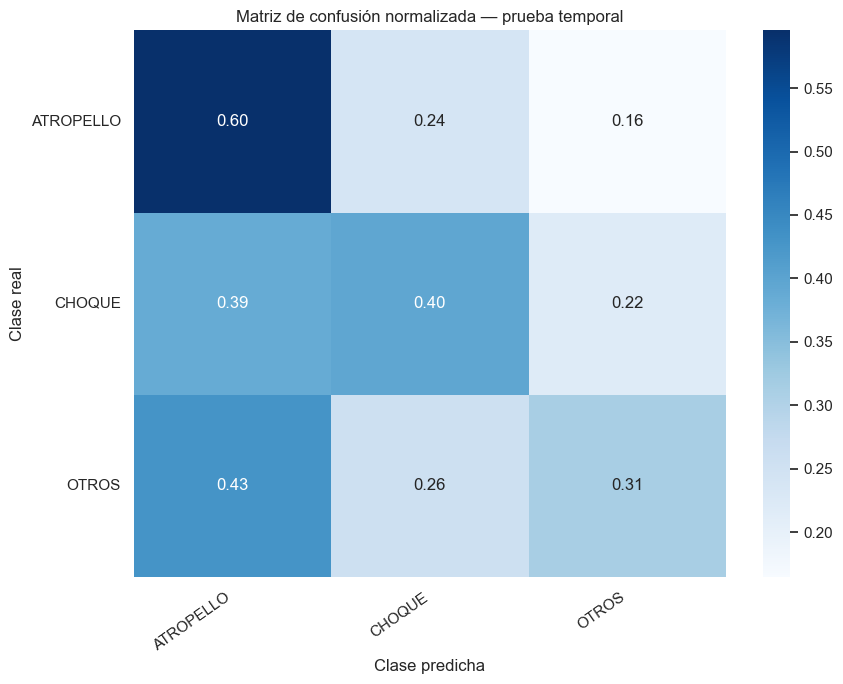

In [27]:
nombres_clases = encoder_objetivo.classes_.tolist()
reporte_clases = pd.DataFrame(classification_report(
    y_test, prediccion_test, labels=clases_codificadas,
    target_names=nombres_clases, output_dict=True, zero_division=0
)).T
display(reporte_clases)

matriz = confusion_matrix(y_test, prediccion_test, labels=clases_codificadas, normalize='true')
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(matriz, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases, ax=ax)
ax.set_title('Matriz de confusión normalizada — prueba temporal')
ax.set_xlabel('Clase predicha')
ax.set_ylabel('Clase real')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Lectura por clase.** El modelo recupera 59,56 % de `ATROPELLO`, 39,56 % de `CHOQUE` y 31,38 % de `OTROS`. Los F1 respectivos son 0,3865, 0,5280 y 0,1811. La agrupación permite detectar parte de los casos residuales, pero `OTROS` conserva una precisión baja (0,1273) porque reúne fenómenos distintos. Por tanto, la agrupación es defendible como salida operativa residual —«no es choque ni atropello»—, no como una tipología homogénea.

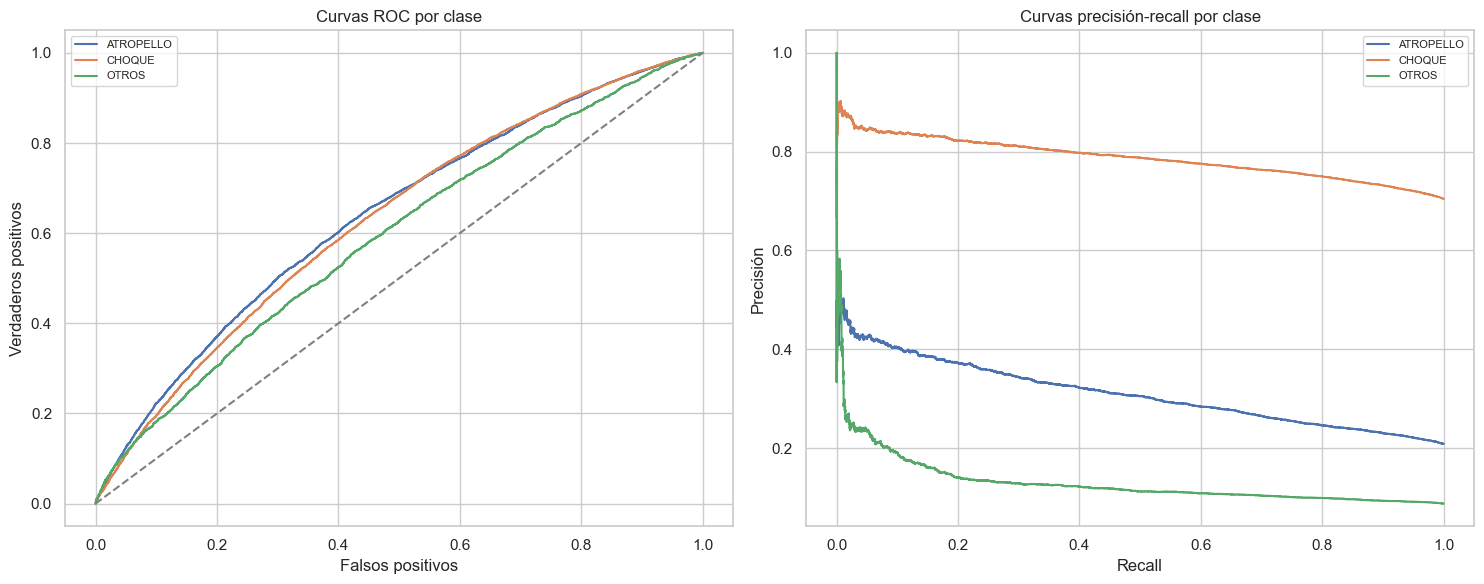

In [28]:
# Curvas ROC y precisión-recall uno contra el resto
y_test_bin = LabelBinarizer().fit(clases_codificadas).transform(y_test)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for posicion, nombre_clase in enumerate(nombres_clases):
    fpr, tpr, _ = roc_curve(y_test_bin[:, posicion], probabilidades_test[:, posicion])
    precision, recall, _ = precision_recall_curve(y_test_bin[:, posicion], probabilidades_test[:, posicion])
    axes[0].plot(fpr, tpr, label=nombre_clase)
    axes[1].plot(recall, precision, label=nombre_clase)
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set(title='Curvas ROC por clase', xlabel='Falsos positivos', ylabel='Verdaderos positivos')
axes[1].set(title='Curvas precisión-recall por clase', xlabel='Recall', ylabel='Precisión')
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [29]:
# Estabilidad por año dentro del periodo de prueba
anios_test = datos_modelo.loc[mascara_test, 'ANIO'].reset_index(drop=True)
metricas_por_anio = []
for anio in sorted(anios_test.unique()):
    mascara_anio = anios_test.eq(anio).to_numpy()
    metricas_anio = calcular_metricas(y_test[mascara_anio], probabilidades_test[mascara_anio])
    metricas_por_anio.append({'ANIO': int(anio), 'FILAS': int(mascara_anio.sum()), **metricas_anio})
metricas_por_anio = pd.DataFrame(metricas_por_anio)
display(metricas_por_anio)

,ANIO,FILAS,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,2024,13798,0.4319,0.4461,0.3706,0.4701,0.4133,0.6236,1.0775,0.6523,0.0325
1,2025,12192,0.4289,0.4260,0.3615,0.4664,0.4069,0.6150,1.0763,0.6513,0.0262
2,2026,6248,0.4281,0.4279,0.3601,0.4676,0.4070,0.6215,1.0686,0.6469,0.0350


,BIN,CASOS,CONFIANZA_MEDIA,EXACTITUD
0,"(-0.001, 0.1]",0,NaN,NaN
1,"(0.1, 0.2]",0,NaN,NaN
2,"(0.2, 0.3]",0,NaN,NaN
3,"(0.3, 0.4]",11463,0.3749,0.3862
4,"(0.4, 0.5]",16094,0.4402,0.4582
5,"(0.5, 0.6]",3933,0.5381,0.4511
6,"(0.6, 0.7]",676,0.6271,0.3861
7,"(0.7, 0.8]",62,0.7352,0.3710
8,"(0.8, 0.9]",10,0.8256,0.5000
9,"(0.9, 1.0]",0,NaN,NaN


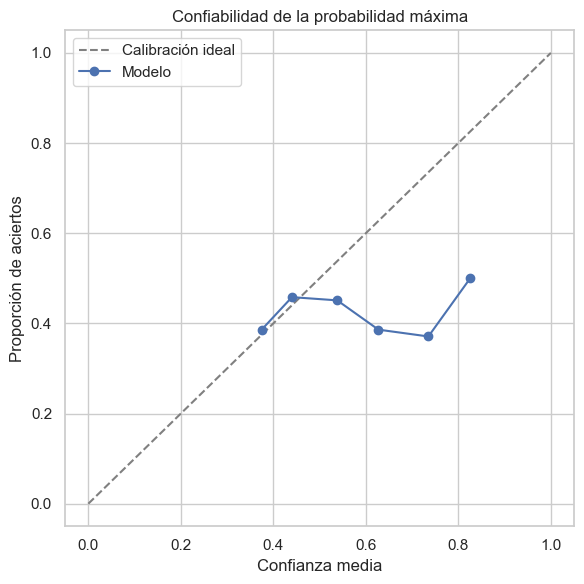

In [30]:
# Confiabilidad de la probabilidad máxima
confianza = probabilidades_test.max(axis=1)
acierto = (prediccion_test == y_test).astype(int)
bins = pd.cut(confianza, bins=np.linspace(0, 1, 11), include_lowest=True)
tabla_calibracion = (
    pd.DataFrame({'BIN': bins, 'CONFIANZA': confianza, 'ACIERTO': acierto})
    .groupby('BIN', observed=False)
    .agg(CASOS=('ACIERTO', 'size'), CONFIANZA_MEDIA=('CONFIANZA', 'mean'), EXACTITUD=('ACIERTO', 'mean'))
    .reset_index()
)
display(tabla_calibracion)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], '--', color='gray', label='Calibración ideal')
ax.plot(tabla_calibracion['CONFIANZA_MEDIA'], tabla_calibracion['EXACTITUD'], marker='o', label='Modelo')
ax.set(title='Confiabilidad de la probabilidad máxima', xlabel='Confianza media', ylabel='Proporción de aciertos')
ax.legend()
plt.tight_layout()
plt.show()

## 13. Importancia de variables

,VARIABLE,IMPORTANCIA_MEDIA,DESVIACION
0,CELDA_Y,0.0254,0.0044
1,ZONA_CIUDAD,0.0146,0.0019
2,CELDA_X,0.0116,0.0016
3,HORA_SIN,0.0109,0.0058
4,HORA_COS,0.0092,0.0041
5,N_CALZADAS,0.0084,0.0032
6,SEMAFORO,0.0068,0.0007
7,N_CARRILES,0.0067,0.0014
8,ESTADO_VIA,0.0030,0.0014
9,CONDICION_VIA,0.0012,0.0009


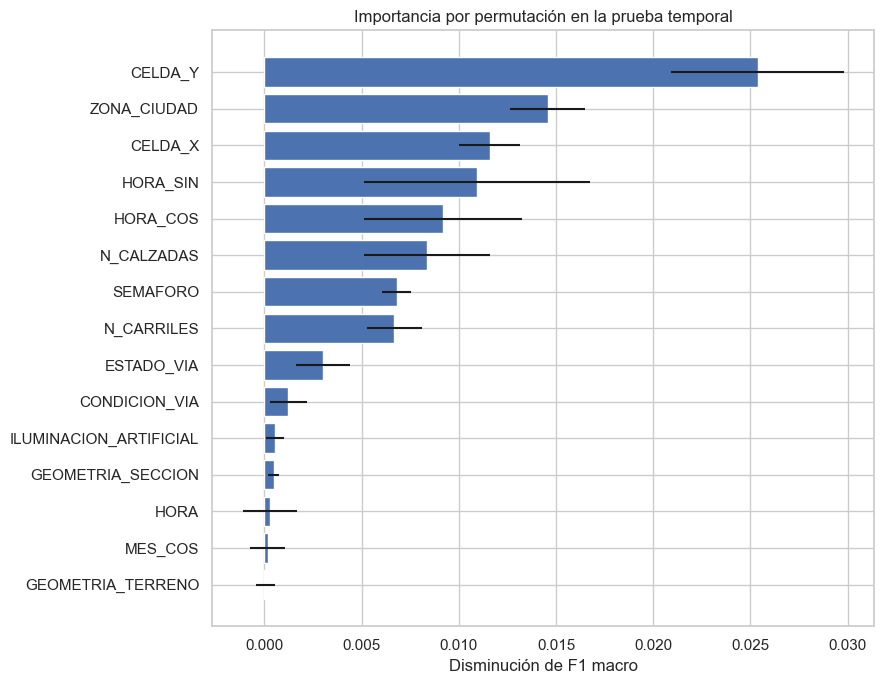

In [31]:
# Importancia por permutación sobre columnas de entrada, usando una muestra del test
rng_importancia = np.random.default_rng(SEMILLA)
cantidad_importancia = min(4_000, len(y_test))
indices_importancia = rng_importancia.choice(len(y_test), size=cantidad_importancia, replace=False)
importancia = permutation_importance(
    modelo_final, X_test.iloc[indices_importancia], y_test[indices_importancia],
    scoring='f1_macro', n_repeats=3, random_state=SEMILLA, n_jobs=1
)
importancia_variables = (
    pd.DataFrame({
        'VARIABLE': X_test.columns,
        'IMPORTANCIA_MEDIA': importancia.importances_mean,
        'DESVIACION': importancia.importances_std,
    })
    .sort_values('IMPORTANCIA_MEDIA', ascending=False)
    .reset_index(drop=True)
)
display(importancia_variables.head(20))

fig, ax = plt.subplots(figsize=(9, 7))
top_importancias = importancia_variables.head(15).sort_values('IMPORTANCIA_MEDIA')
ax.barh(top_importancias['VARIABLE'], top_importancias['IMPORTANCIA_MEDIA'], xerr=top_importancias['DESVIACION'])
ax.set_title('Importancia por permutación en la prueba temporal')
ax.set_xlabel('Disminución de F1 macro')
plt.tight_layout()
plt.show()

## 14. Exportación del modelo y trazabilidad

In [32]:
CARPETA_ARTEFACTOS.mkdir(parents=True, exist_ok=True)
RUTA_MODELO = CARPETA_ARTEFACTOS / 'modelo_clase_accidente.joblib'
RUTA_ENCODER = CARPETA_ARTEFACTOS / 'encoder_clase_accidente.joblib'
RUTA_METADATA = CARPETA_ARTEFACTOS / 'metadata_modelo_clase_accidente.json'
RUTA_VALIDACION = CARPETA_ARTEFACTOS / 'metricas_validacion.csv'
RUTA_TEST = CARPETA_ARTEFACTOS / 'metricas_test.csv'
RUTA_REPORTE_CLASES = CARPETA_ARTEFACTOS / 'metricas_test_por_clase.csv'
RUTA_ZONAS = CARPETA_ARTEFACTOS / 'zonas_ciudad.csv'

joblib.dump(modelo_final, RUTA_MODELO)
joblib.dump(encoder_objetivo, RUTA_ENCODER)
resultados_validacion.to_csv(RUTA_VALIDACION, index=False, encoding='utf-8-sig')
comparacion_test.to_csv(RUTA_TEST, index=False, encoding='utf-8-sig')
reporte_clases.to_csv(RUTA_REPORTE_CLASES, encoding='utf-8-sig')
centroides_zona.to_csv(RUTA_ZONAS, index=False, encoding='utf-8-sig')

metadata_modelo = {
    'objetivo': 'CLASE_ACCIDENTE_AGRUPADA condicionada a la ocurrencia del evento',
    'modelo': NOMBRE_GANADOR,
    'escenario': ESCENARIO_GANADOR,
    'parametros': PARAMETROS_GANADOR,
    'semilla': SEMILLA,
    'versiones_software': {
        'python': sys.version.split()[0],
        'numpy': np.__version__,
        'pandas': pd.__version__,
        'scikit-learn': __import__('sklearn').__version__,
        'xgboost': __import__('xgboost').__version__,
        'joblib': joblib.__version__,
    },
    'entrenamiento_hasta': ANIO_FIN_VALIDACION,
    'prueba_desde': ANIO_FIN_VALIDACION + 1,
    'clases_modeladas': encoder_objetivo.classes_.tolist(),
    'agrupacion_clases_originales': {
        catalogo_clases[int(codigo)]: grupo
        for codigo, grupo in AGRUPACION_CLASES.items()
    },
    'clase_excluida': {
        'codigo': CODIGO_SIN_INFORMACION,
        'descripcion': catalogo_clases[CODIGO_SIN_INFORMACION],
    },
    'zonificacion': {
        'numero_zonas': NUMERO_ZONAS,
        'fuente_centroides': str(RUTA_OCURRENCIA.relative_to(RAIZ_PROYECTO)),
        'metodo_asignacion': 'Centro de celda de 500 m al centroide de ocurrencia más cercano',
    },
    'columnas_entrada_modelo': X_desarrollo.columns.tolist(),
    'variables_postevento_bloqueadas': sorted(VARIABLES_POSTEVENTO_BLOQUEADAS),
    'metricas_test': {clave: float(valor) for clave, valor in metricas_test.items()},
    'nota_operativa': 'Antes de predecir deben asignarse ZONA_CIUDAD y las variables ciclicas.',
}
with open(RUTA_METADATA, 'w', encoding='utf-8') as archivo:
    json.dump(metadata_modelo, archivo, ensure_ascii=False, indent=2)

print('Artefactos exportados:')
for ruta in [RUTA_MODELO, RUTA_ENCODER, RUTA_METADATA, RUTA_VALIDACION, RUTA_TEST, RUTA_REPORTE_CLASES, RUTA_ZONAS]:
    print(f'- {ruta.relative_to(RAIZ_PROYECTO)}')

Artefactos exportados:
- modelo/artefactos/clase_accidente/modelo_clase_accidente.joblib
- modelo/artefactos/clase_accidente/encoder_clase_accidente.joblib
- modelo/artefactos/clase_accidente/metadata_modelo_clase_accidente.json
- modelo/artefactos/clase_accidente/metricas_validacion.csv
- modelo/artefactos/clase_accidente/metricas_test.csv
- modelo/artefactos/clase_accidente/metricas_test_por_clase.csv
- modelo/artefactos/clase_accidente/zonas_ciudad.csv


## 15. Ejemplo de consulta al modelo

In [33]:
def agregar_zona_ciudad(df):
    salida = df.copy()
    if 'ZONA_CIUDAD' in salida and salida['ZONA_CIUDAD'].notna().all():
        salida['ZONA_CIUDAD'] = salida['ZONA_CIUDAD'].astype('int16')
        return salida
    faltantes = {'CELDA_X', 'CELDA_Y'} - set(salida.columns)
    if faltantes:
        raise ValueError(f'Para calcular ZONA_CIUDAD faltan: {sorted(faltantes)}')
    x_centro = (salida['CELDA_X'].to_numpy() + 0.5) * TAMANO_CELDA_METROS
    y_centro = (salida['CELDA_Y'].to_numpy() + 0.5) * TAMANO_CELDA_METROS
    lon, lat = bogota_a_wgs84.transform(x_centro, y_centro)
    _, posiciones = arbol_zonas.query(np.column_stack([lat, lon]), k=1)
    salida['ZONA_CIUDAD'] = (
        centroides_zona.iloc[posiciones]['ZONA_CIUDAD'].to_numpy().astype('int16')
    )
    return salida

def predecir_clase_accidente(registro, modelo=modelo_final):
    entrada = agregar_zona_ciudad(pd.DataFrame([registro]))
    entrada = agregar_variables_ciclicas(entrada)
    entrada = entrada[X_desarrollo.columns]
    probabilidades = ordenar_probabilidades(modelo, entrada, clases_codificadas)[0]
    resultado = pd.DataFrame({
        'CLASE_CODIFICADA': clases_codificadas,
        'CLASE_ACCIDENTE_AGRUPADA': encoder_objetivo.classes_,
        'PROBABILIDAD': probabilidades,
    })
    return resultado.sort_values('PROBABILIDAD', ascending=False).reset_index(drop=True)

# Se toma una fila real de prueba únicamente para demostrar el contrato de entrada
columnas_crudas_ejemplo = [
    'CELDA_X', 'CELDA_Y', 'ANIO', 'MES', 'DIA_SEMANA', 'HORA',
    *COLUMNAS_VIA, 'TEMPERATURA_2M', 'HUMEDAD_RELATIVA_2M',
    'SENSACION_TERMICA', 'PRECIPITACION', 'LLUVIA', 'NUBOSIDAD',
    'PRESION_SUPERFICIE', 'VELOCIDAD_VIENTO_10M', 'DIRECCION_VIENTO_10M'
]
registro_ejemplo = datos_modelo.loc[mascara_test, columnas_crudas_ejemplo].iloc[0].to_dict()
display(predecir_clase_accidente(registro_ejemplo))

,CLASE_CODIFICADA,CLASE_ACCIDENTE_AGRUPADA,PROBABILIDAD
0,0,ATROPELLO,0.4319
1,1,CHOQUE,0.3438
2,2,OTROS,0.2243


## 16. Conclusiones automáticas del experimento

In [34]:
delta_f1_baseline = metricas_test['F1_macro'] - metricas_baseline_test['F1_macro']
clase_mas_dificil = reporte_clases.loc[nombres_clases, 'f1-score'].idxmin()
clase_mejor = reporte_clases.loc[nombres_clases, 'f1-score'].idxmax()

print('Conclusiones:')
print(f'1. El diseño seleccionado en validación fue {NOMBRE_GANADOR} / {ESCENARIO_GANADOR}.')
print(f'2. En la prueba temporal obtuvo F1 macro={metricas_test["F1_macro"]:.4f} y balanced accuracy={metricas_test["Balanced_Accuracy"]:.4f}.')
print(f'3. La mejora de F1 macro frente a la línea base fue {delta_f1_baseline:+.4f}.')
print(f'4. La clase con menor F1 fue {clase_mas_dificil}; la mejor fue {clase_mejor}.')
print(f'5. El log loss fue {metricas_test["Log_Loss"]:.4f} y el ECE fue {metricas_test["ECE_10_bins"]:.4f}.')
print('6. OTROS es una clase residual heterogénea; su probabilidad debe interpretarse y monitorearse con cautela.')

Conclusiones:
1. El diseño seleccionado en validación fue XGBOOST / SIN_CLIMA.
2. En la prueba temporal obtuvo F1 macro=0.3652 y balanced accuracy=0.4350.
3. La mejora de F1 macro frente a la línea base fue +0.0897.
4. La clase con menor F1 fue OTROS; la mejor fue CHOQUE.
5. El log loss fue 1.0753 y el ECE fue 0.0295.
6. OTROS es una clase residual heterogénea; su probabilidad debe interpretarse y monitorearse con cautela.
